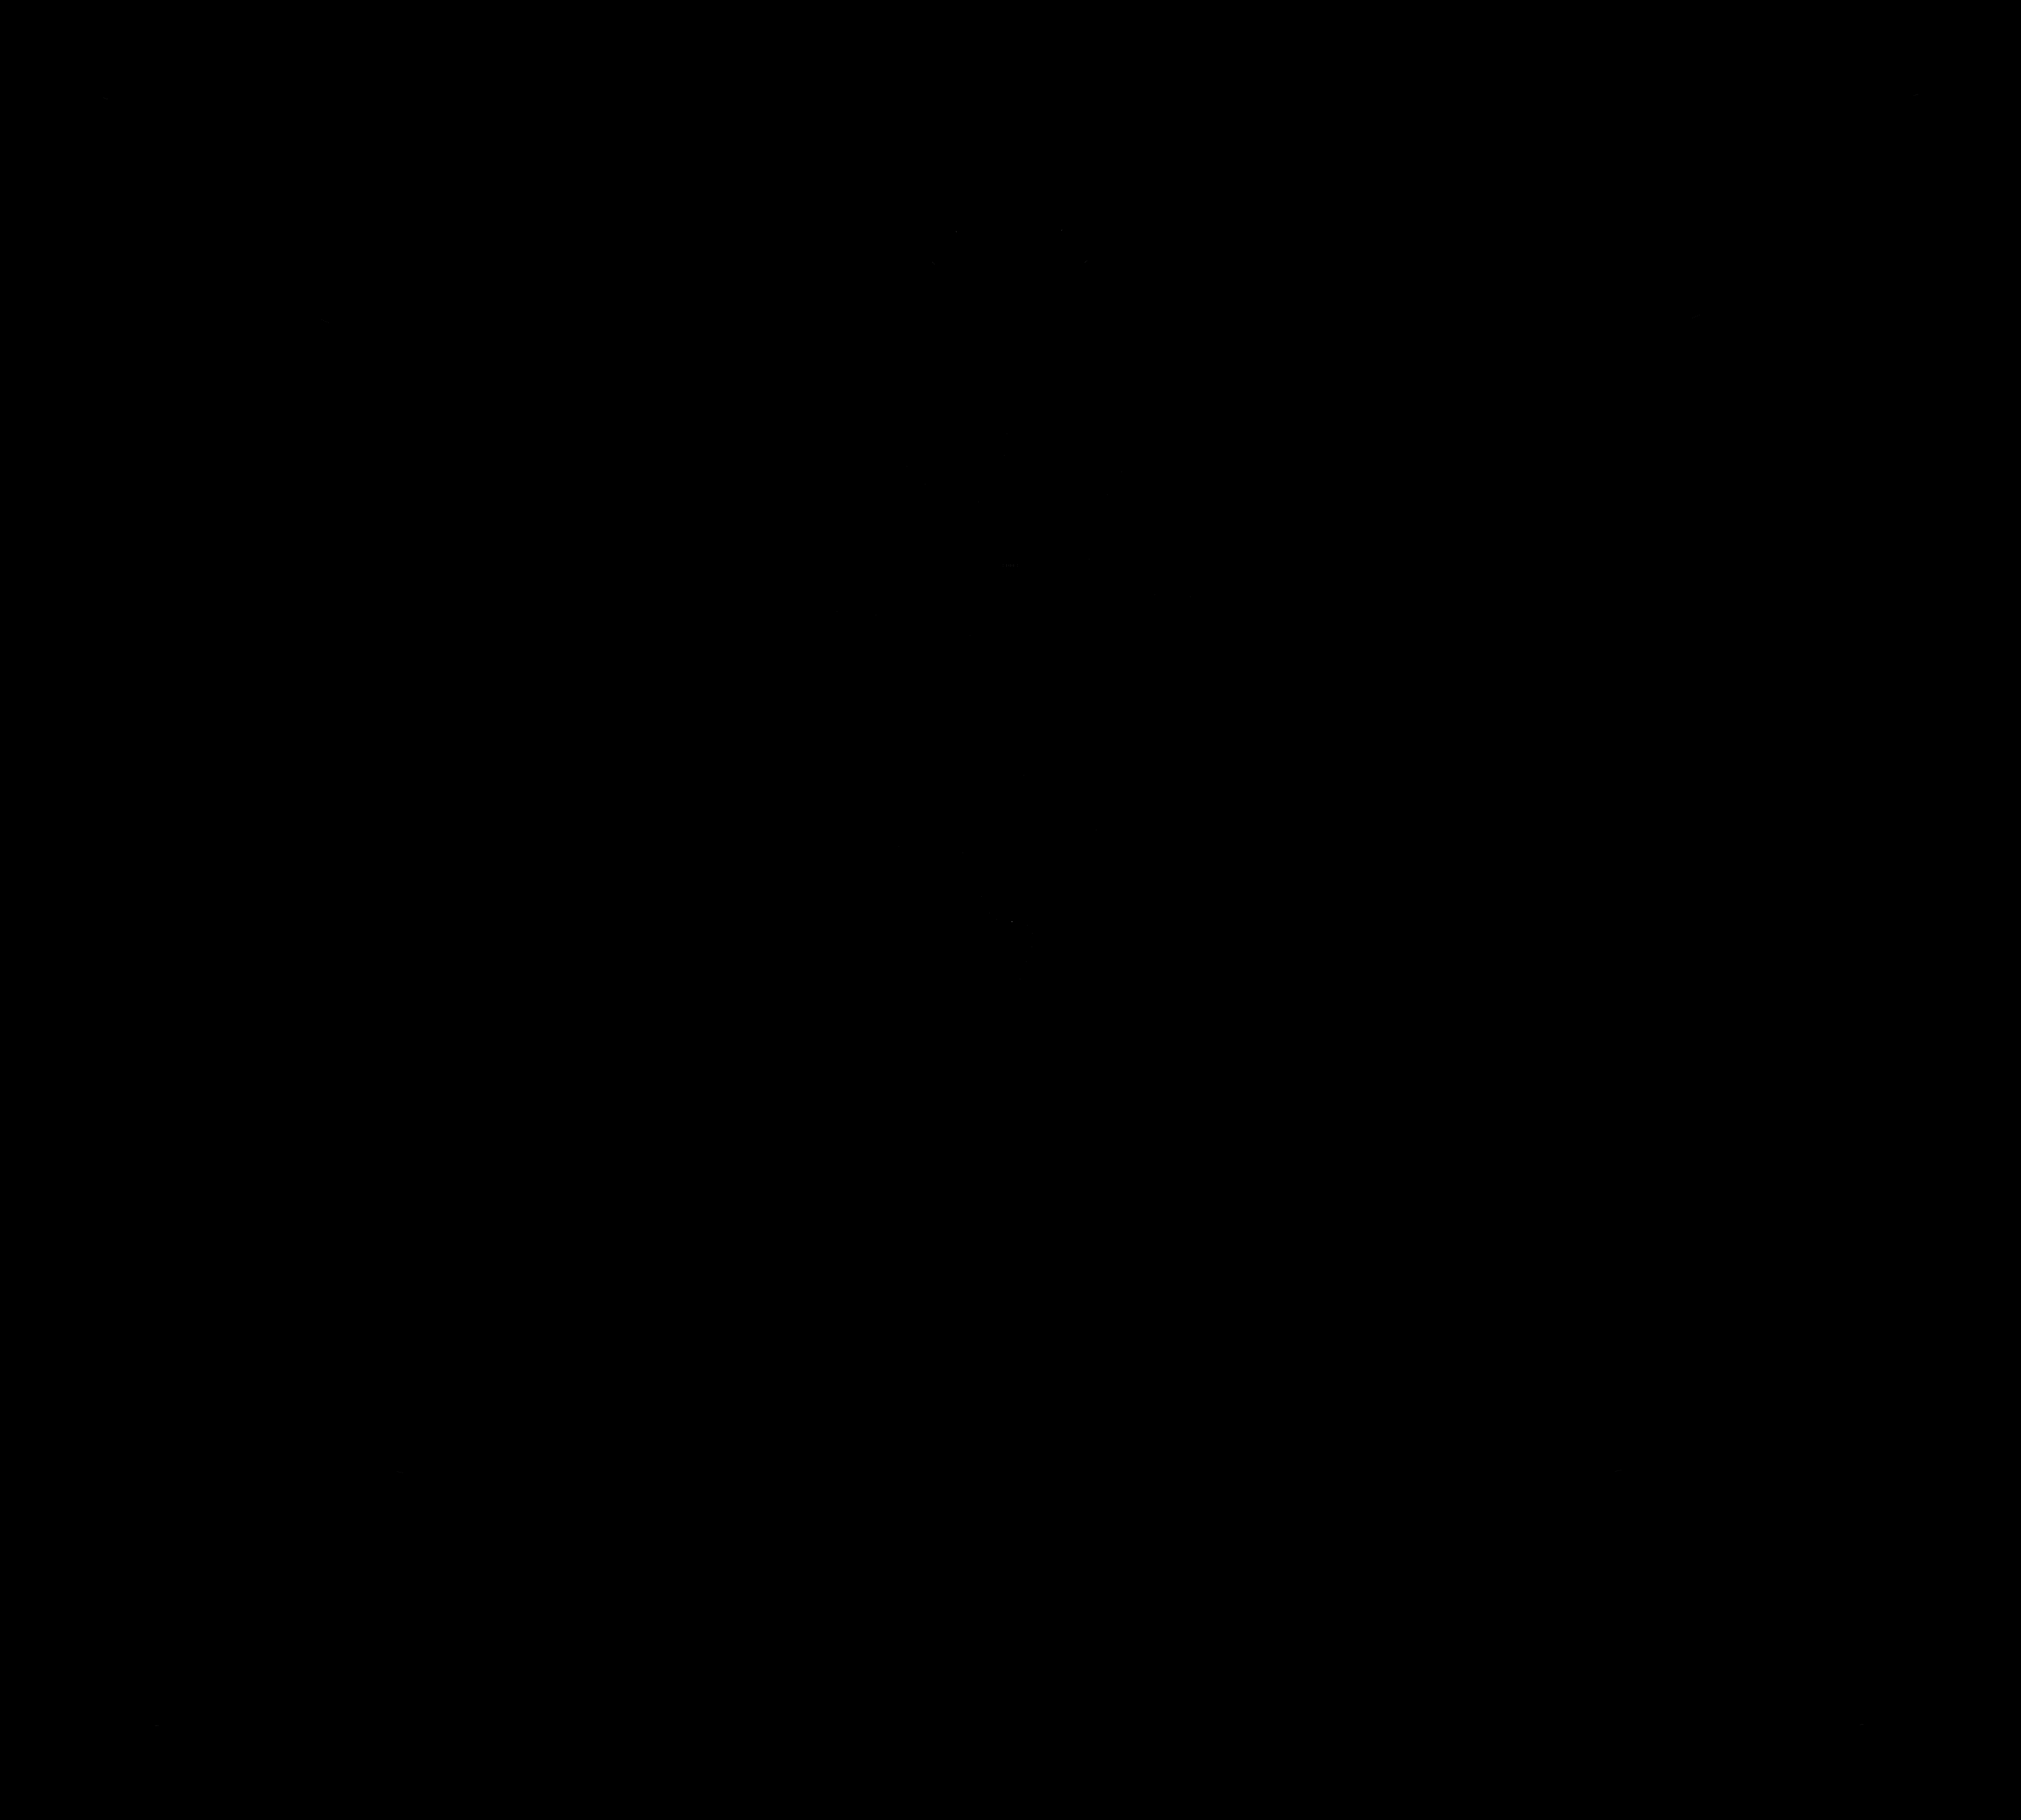

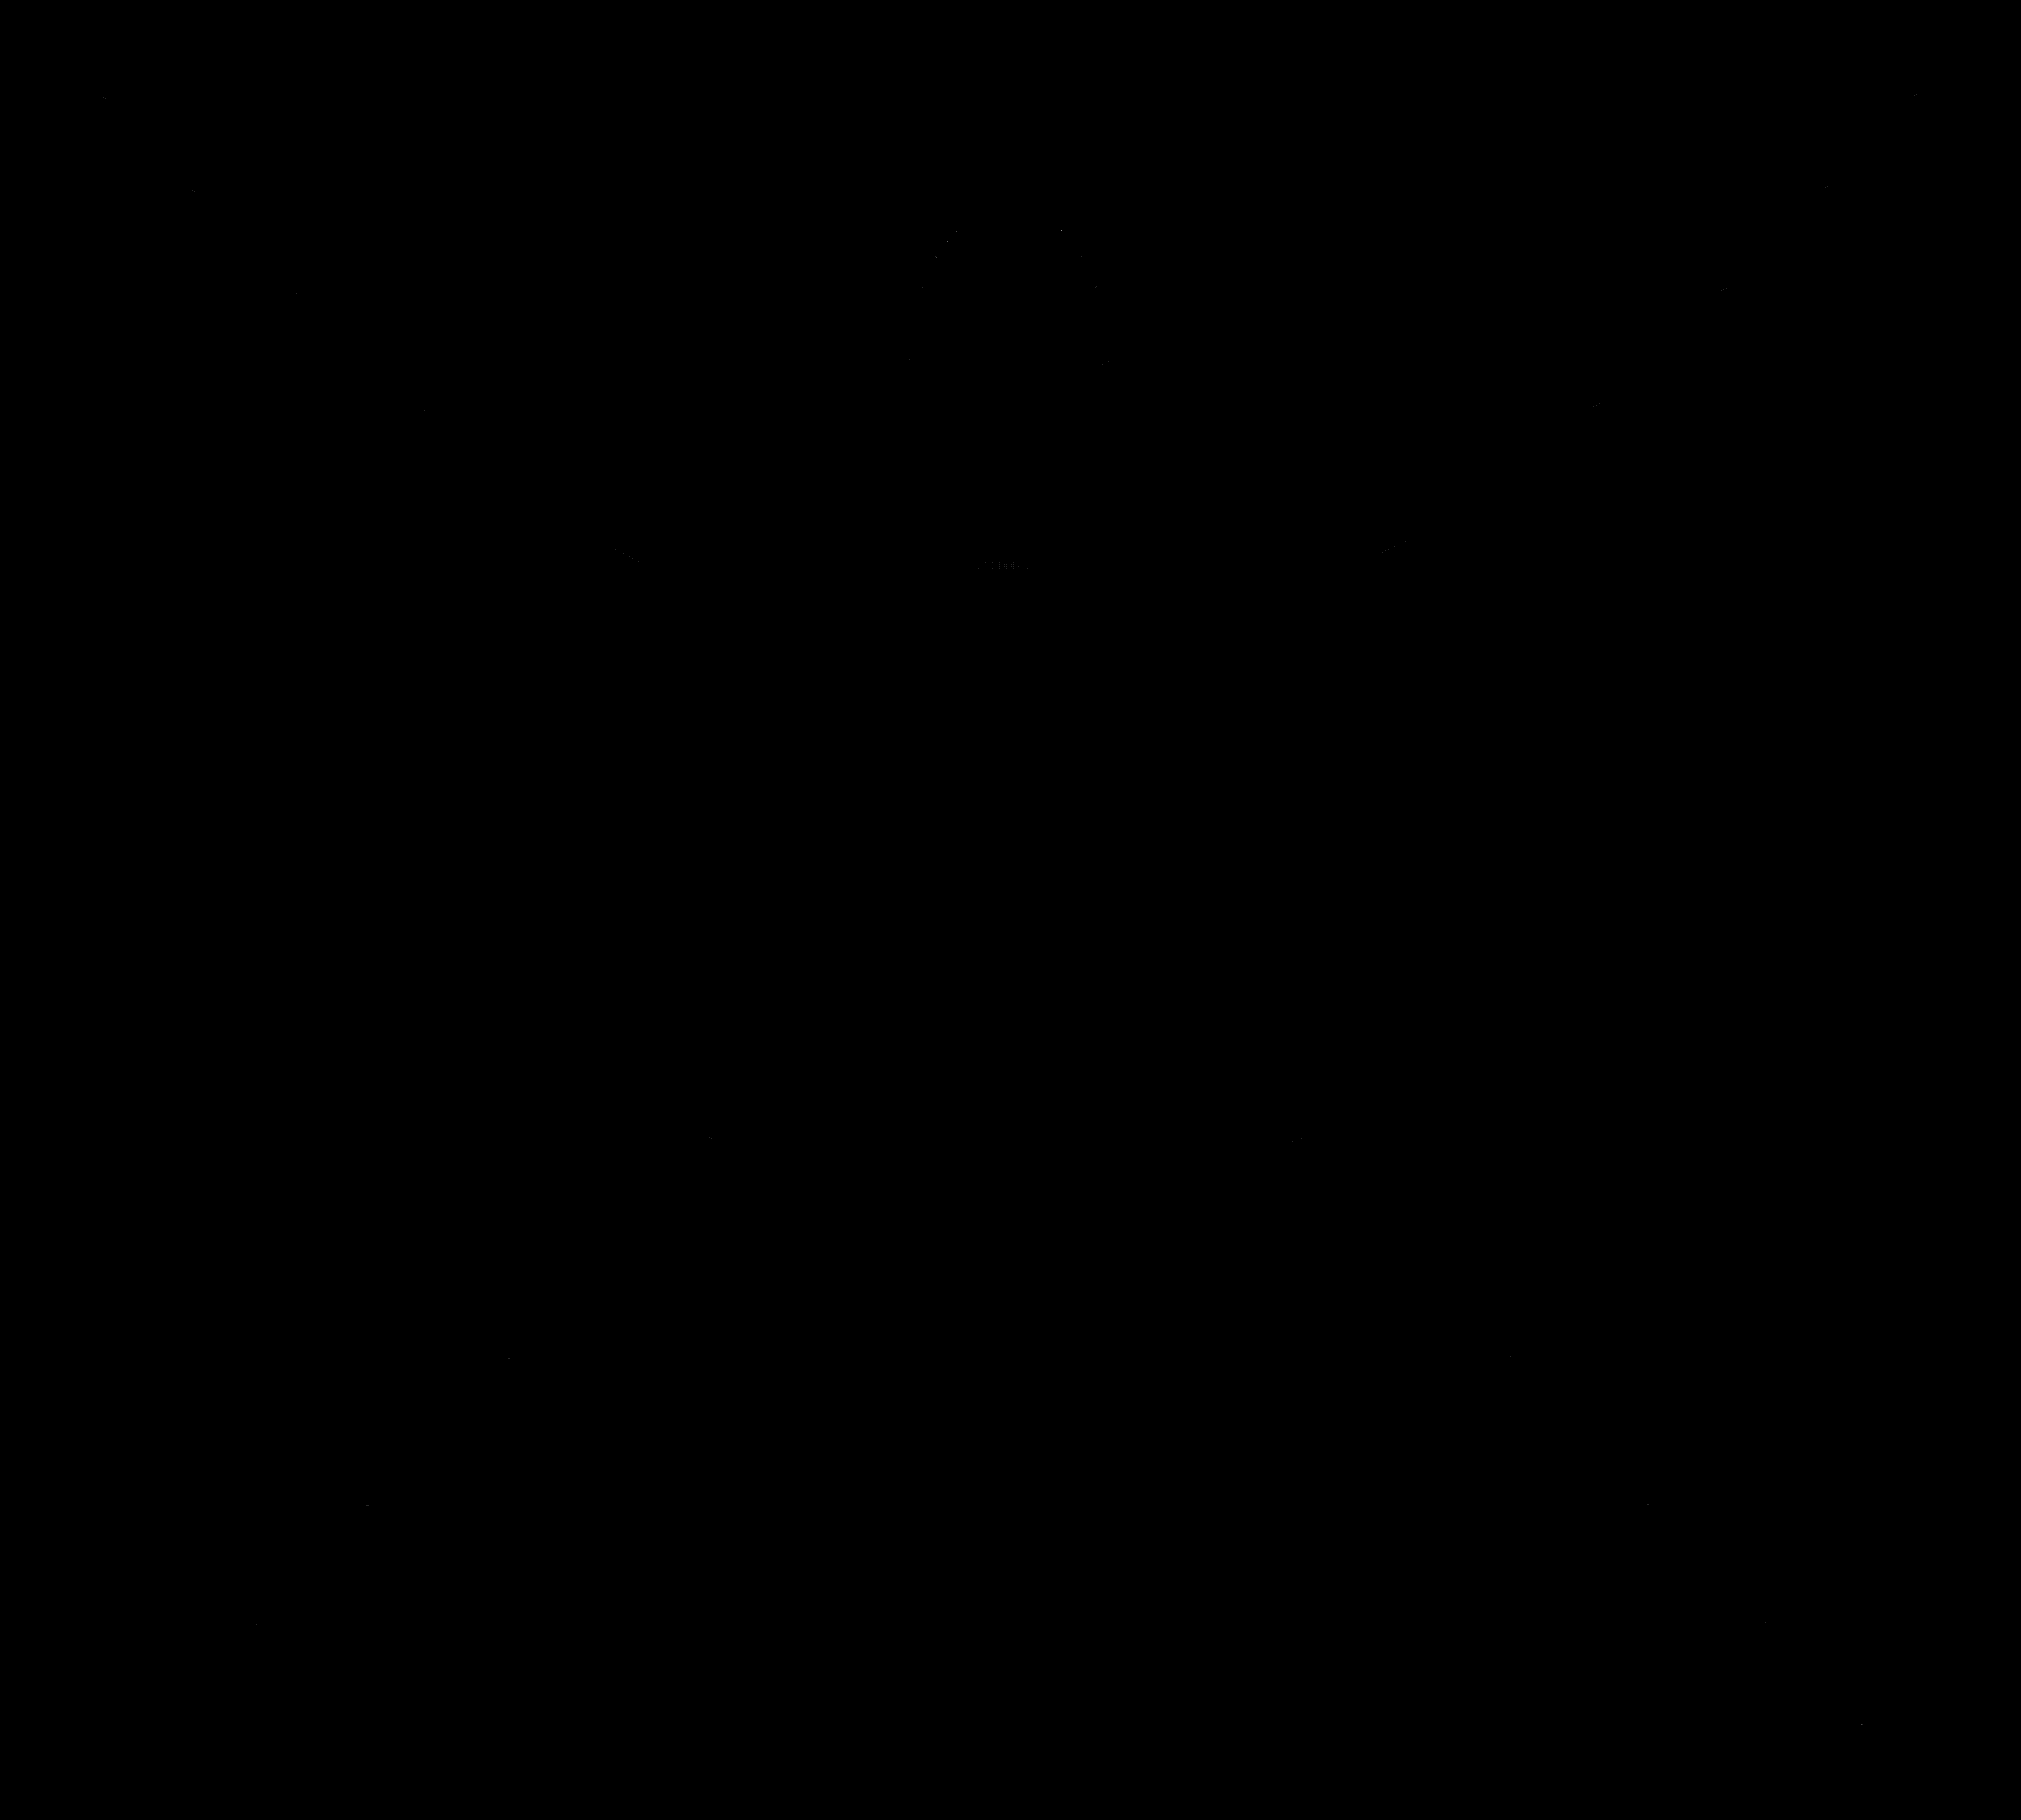

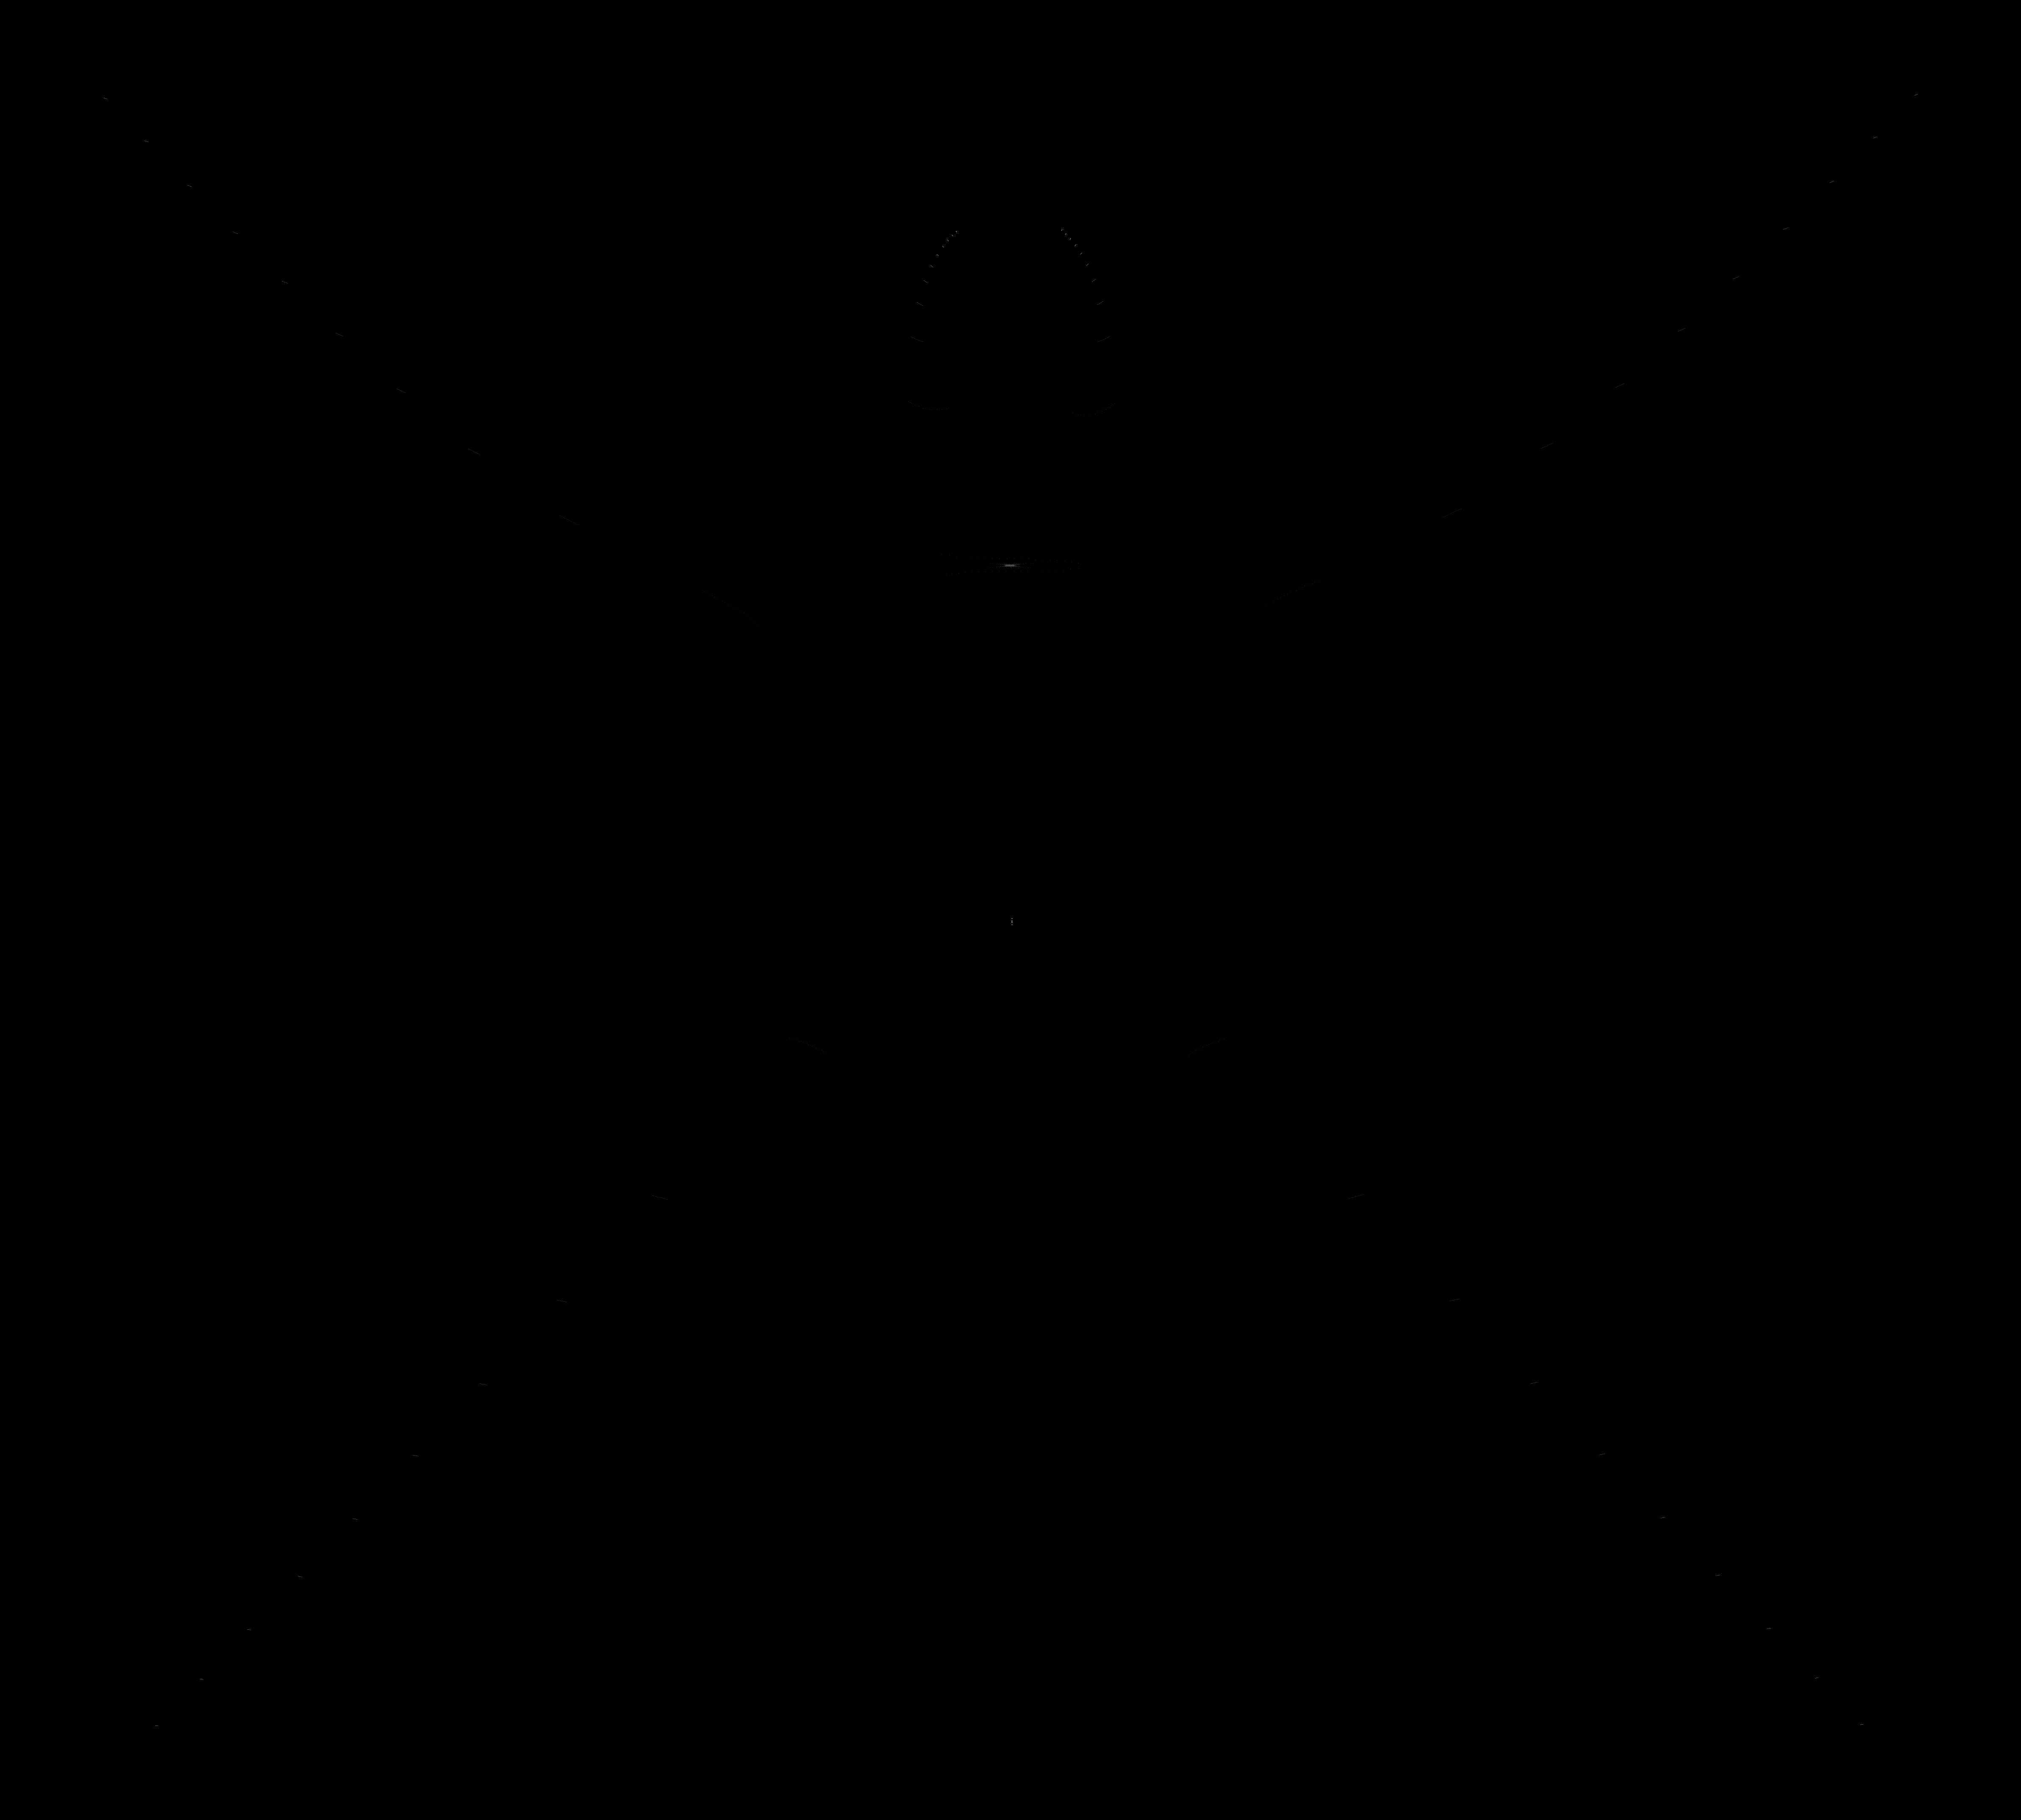

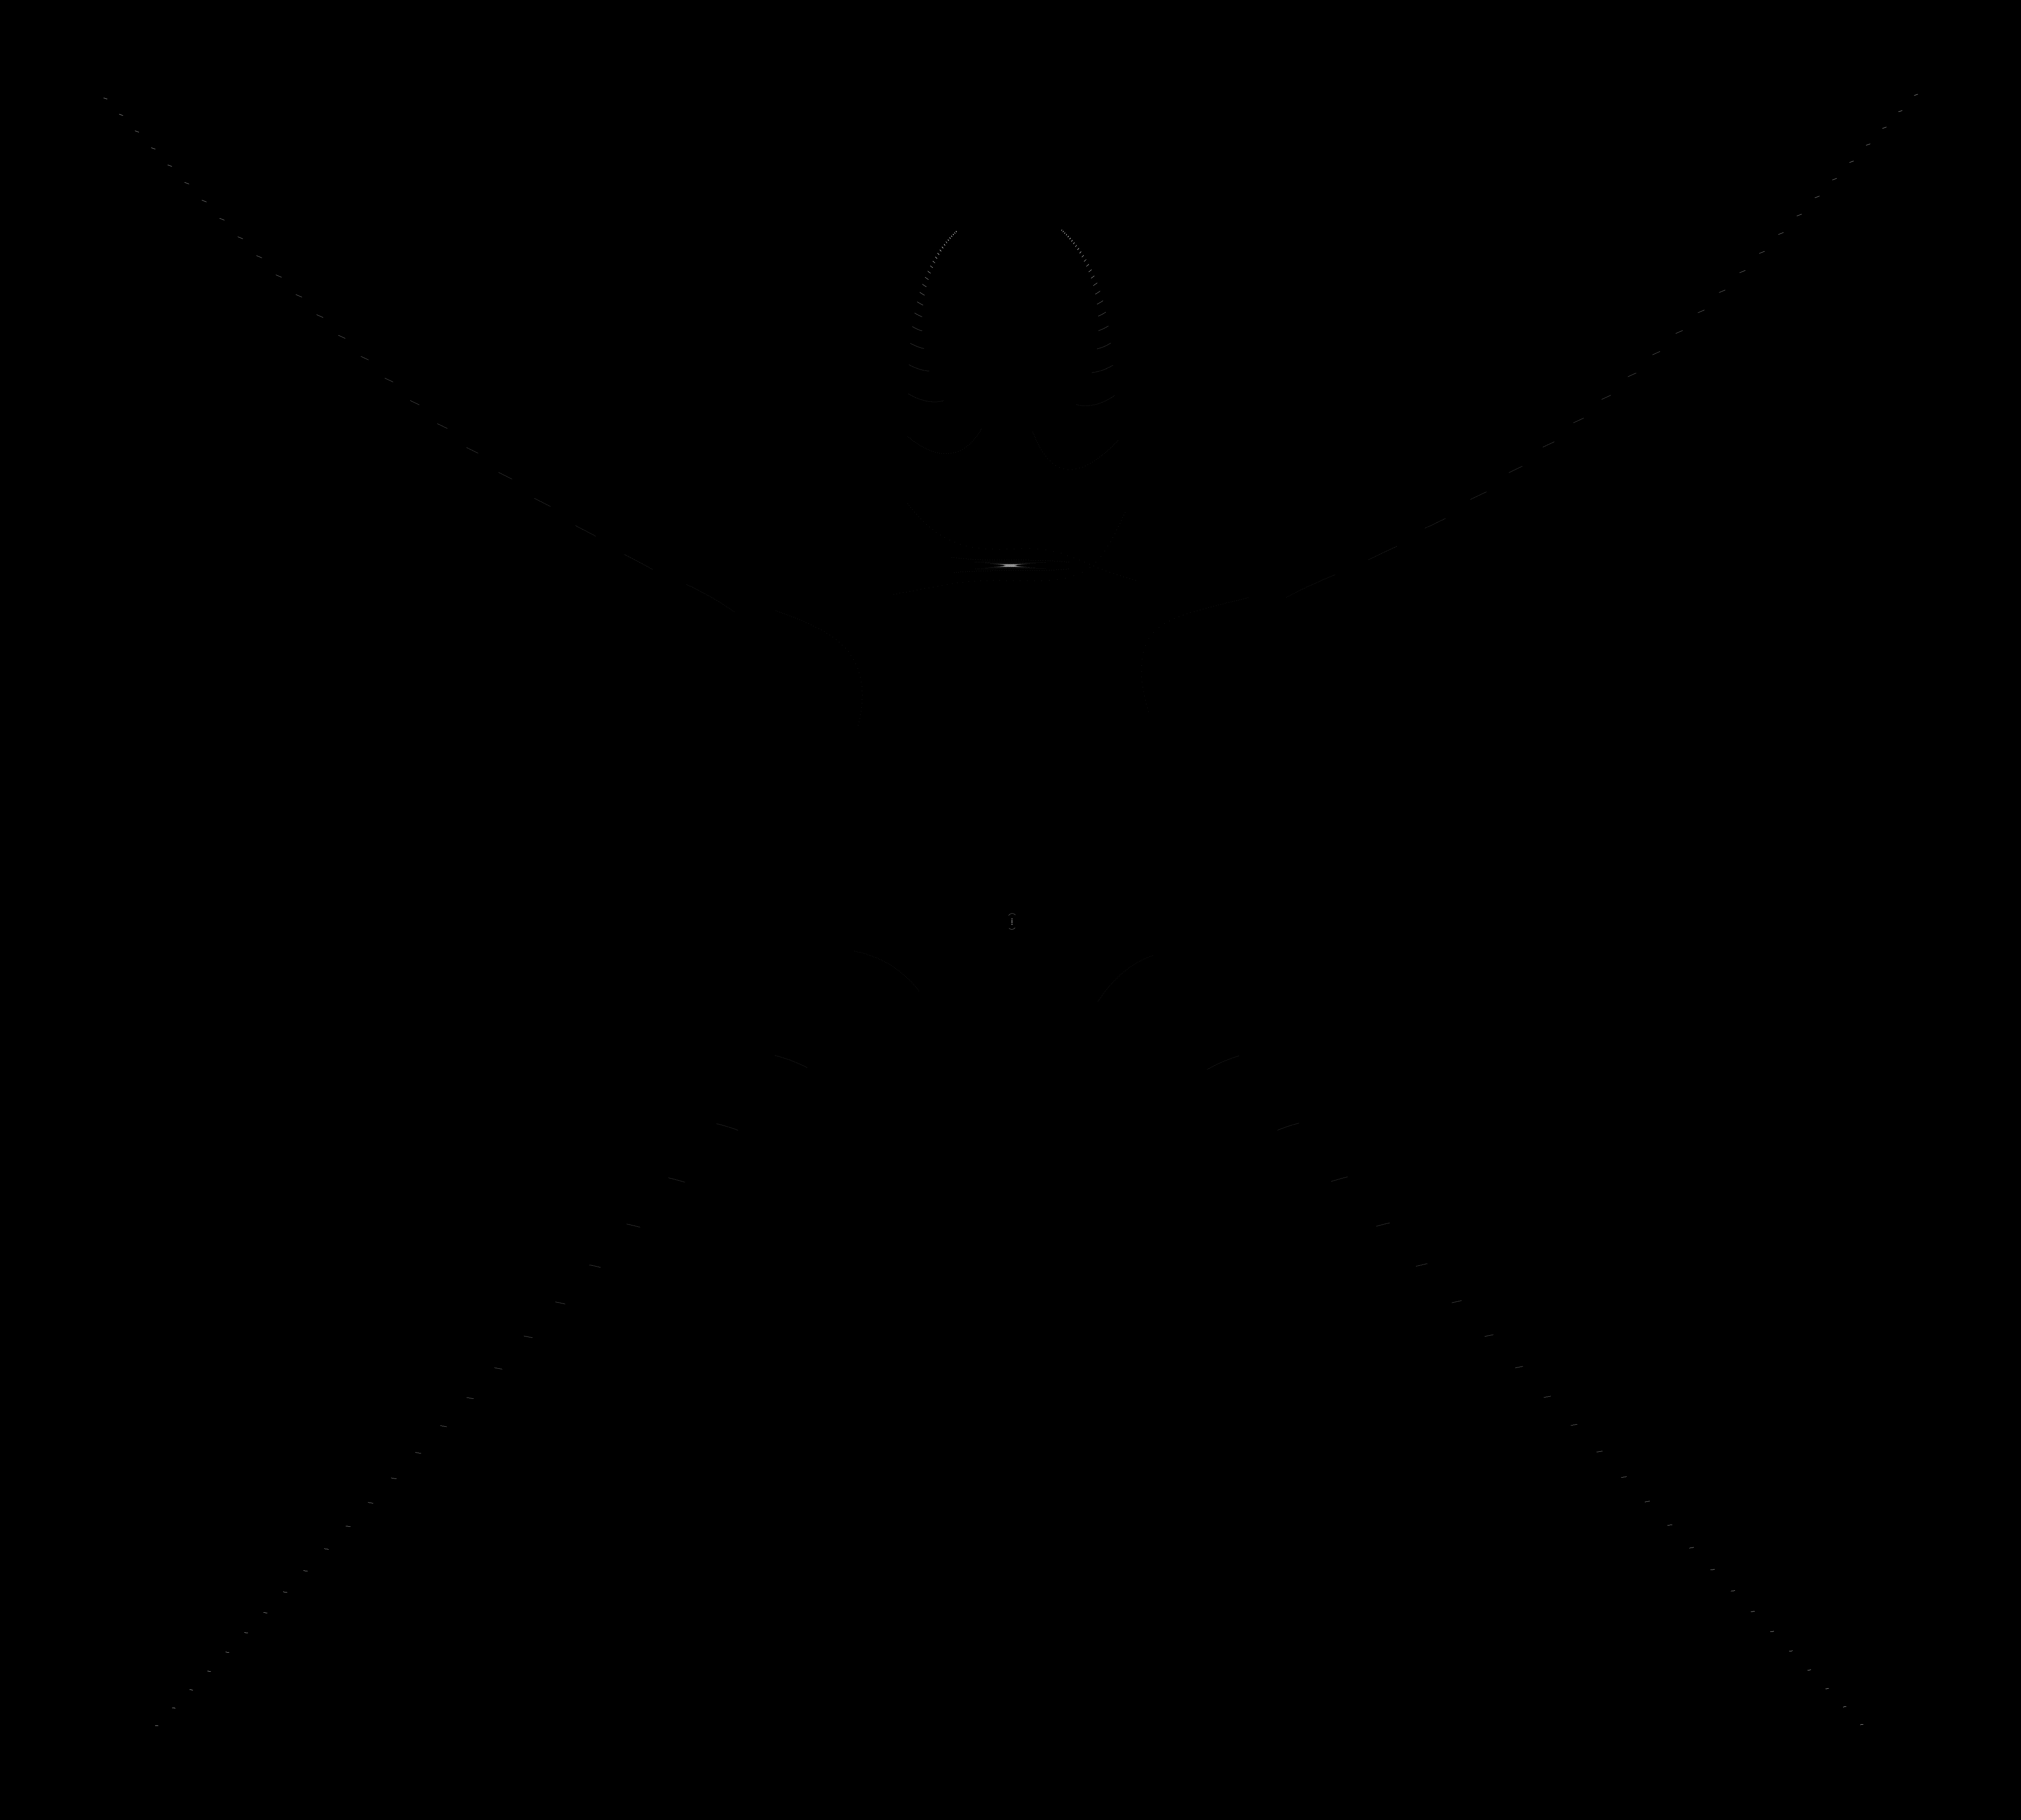

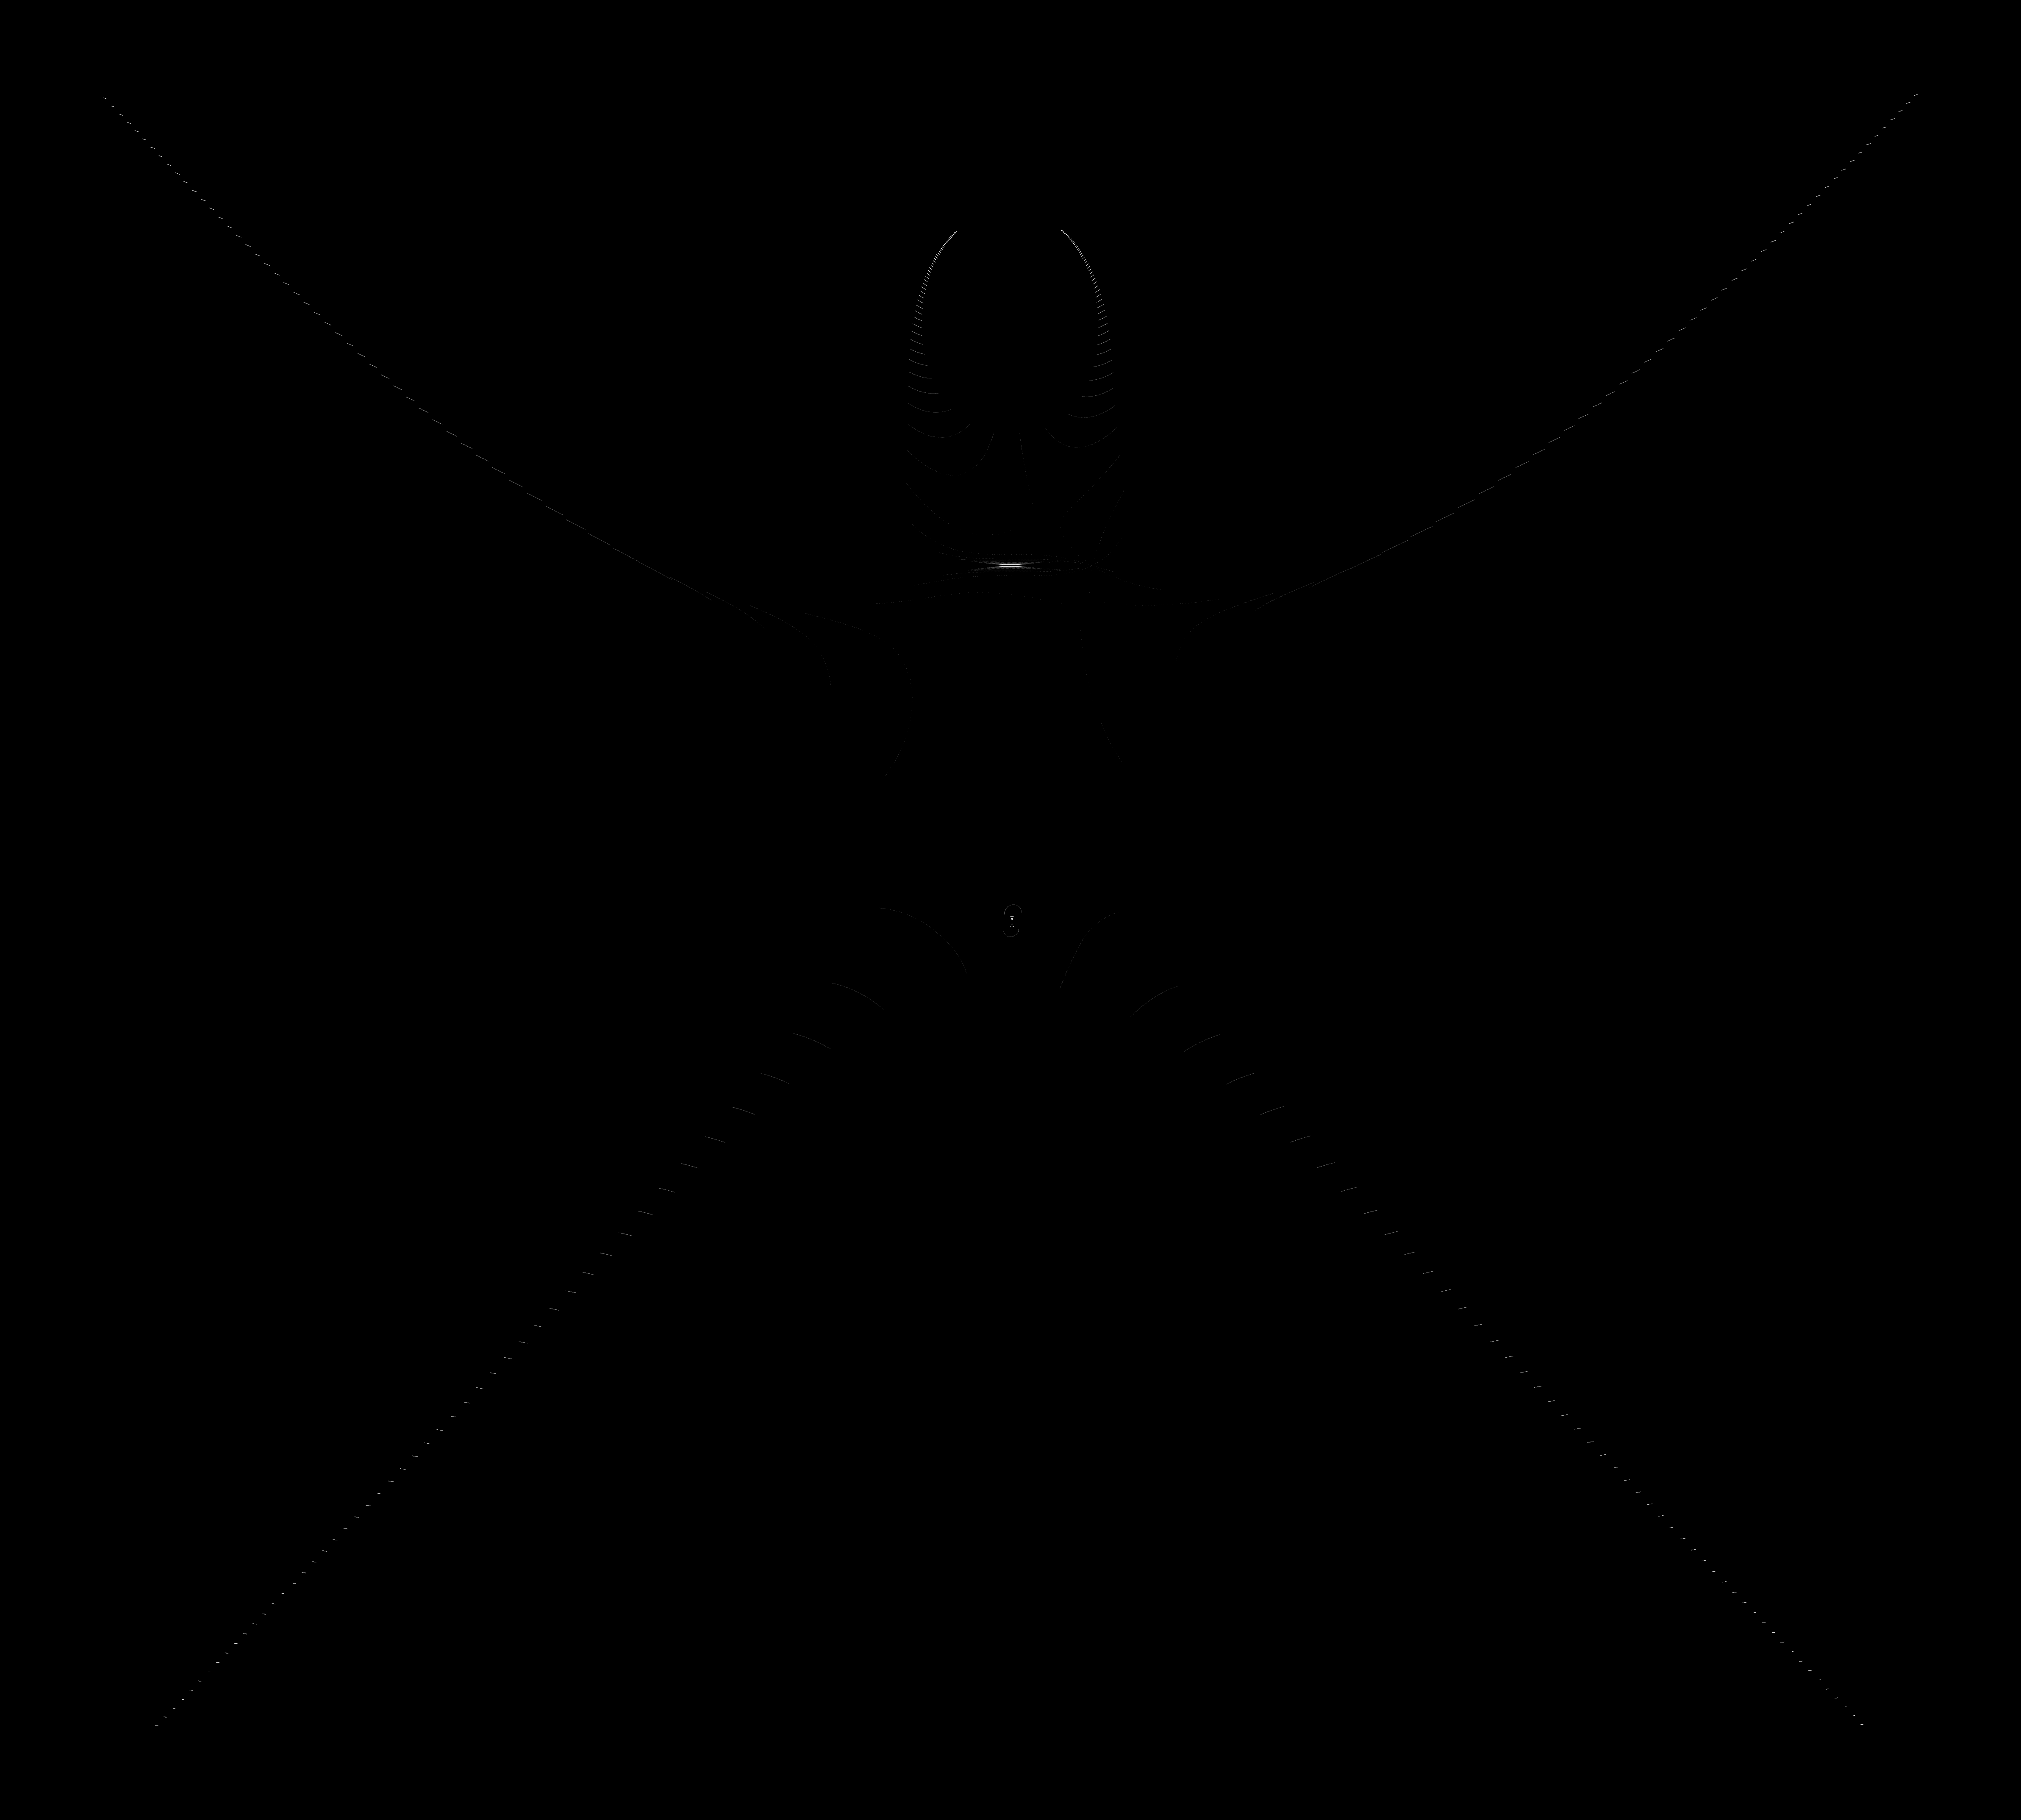

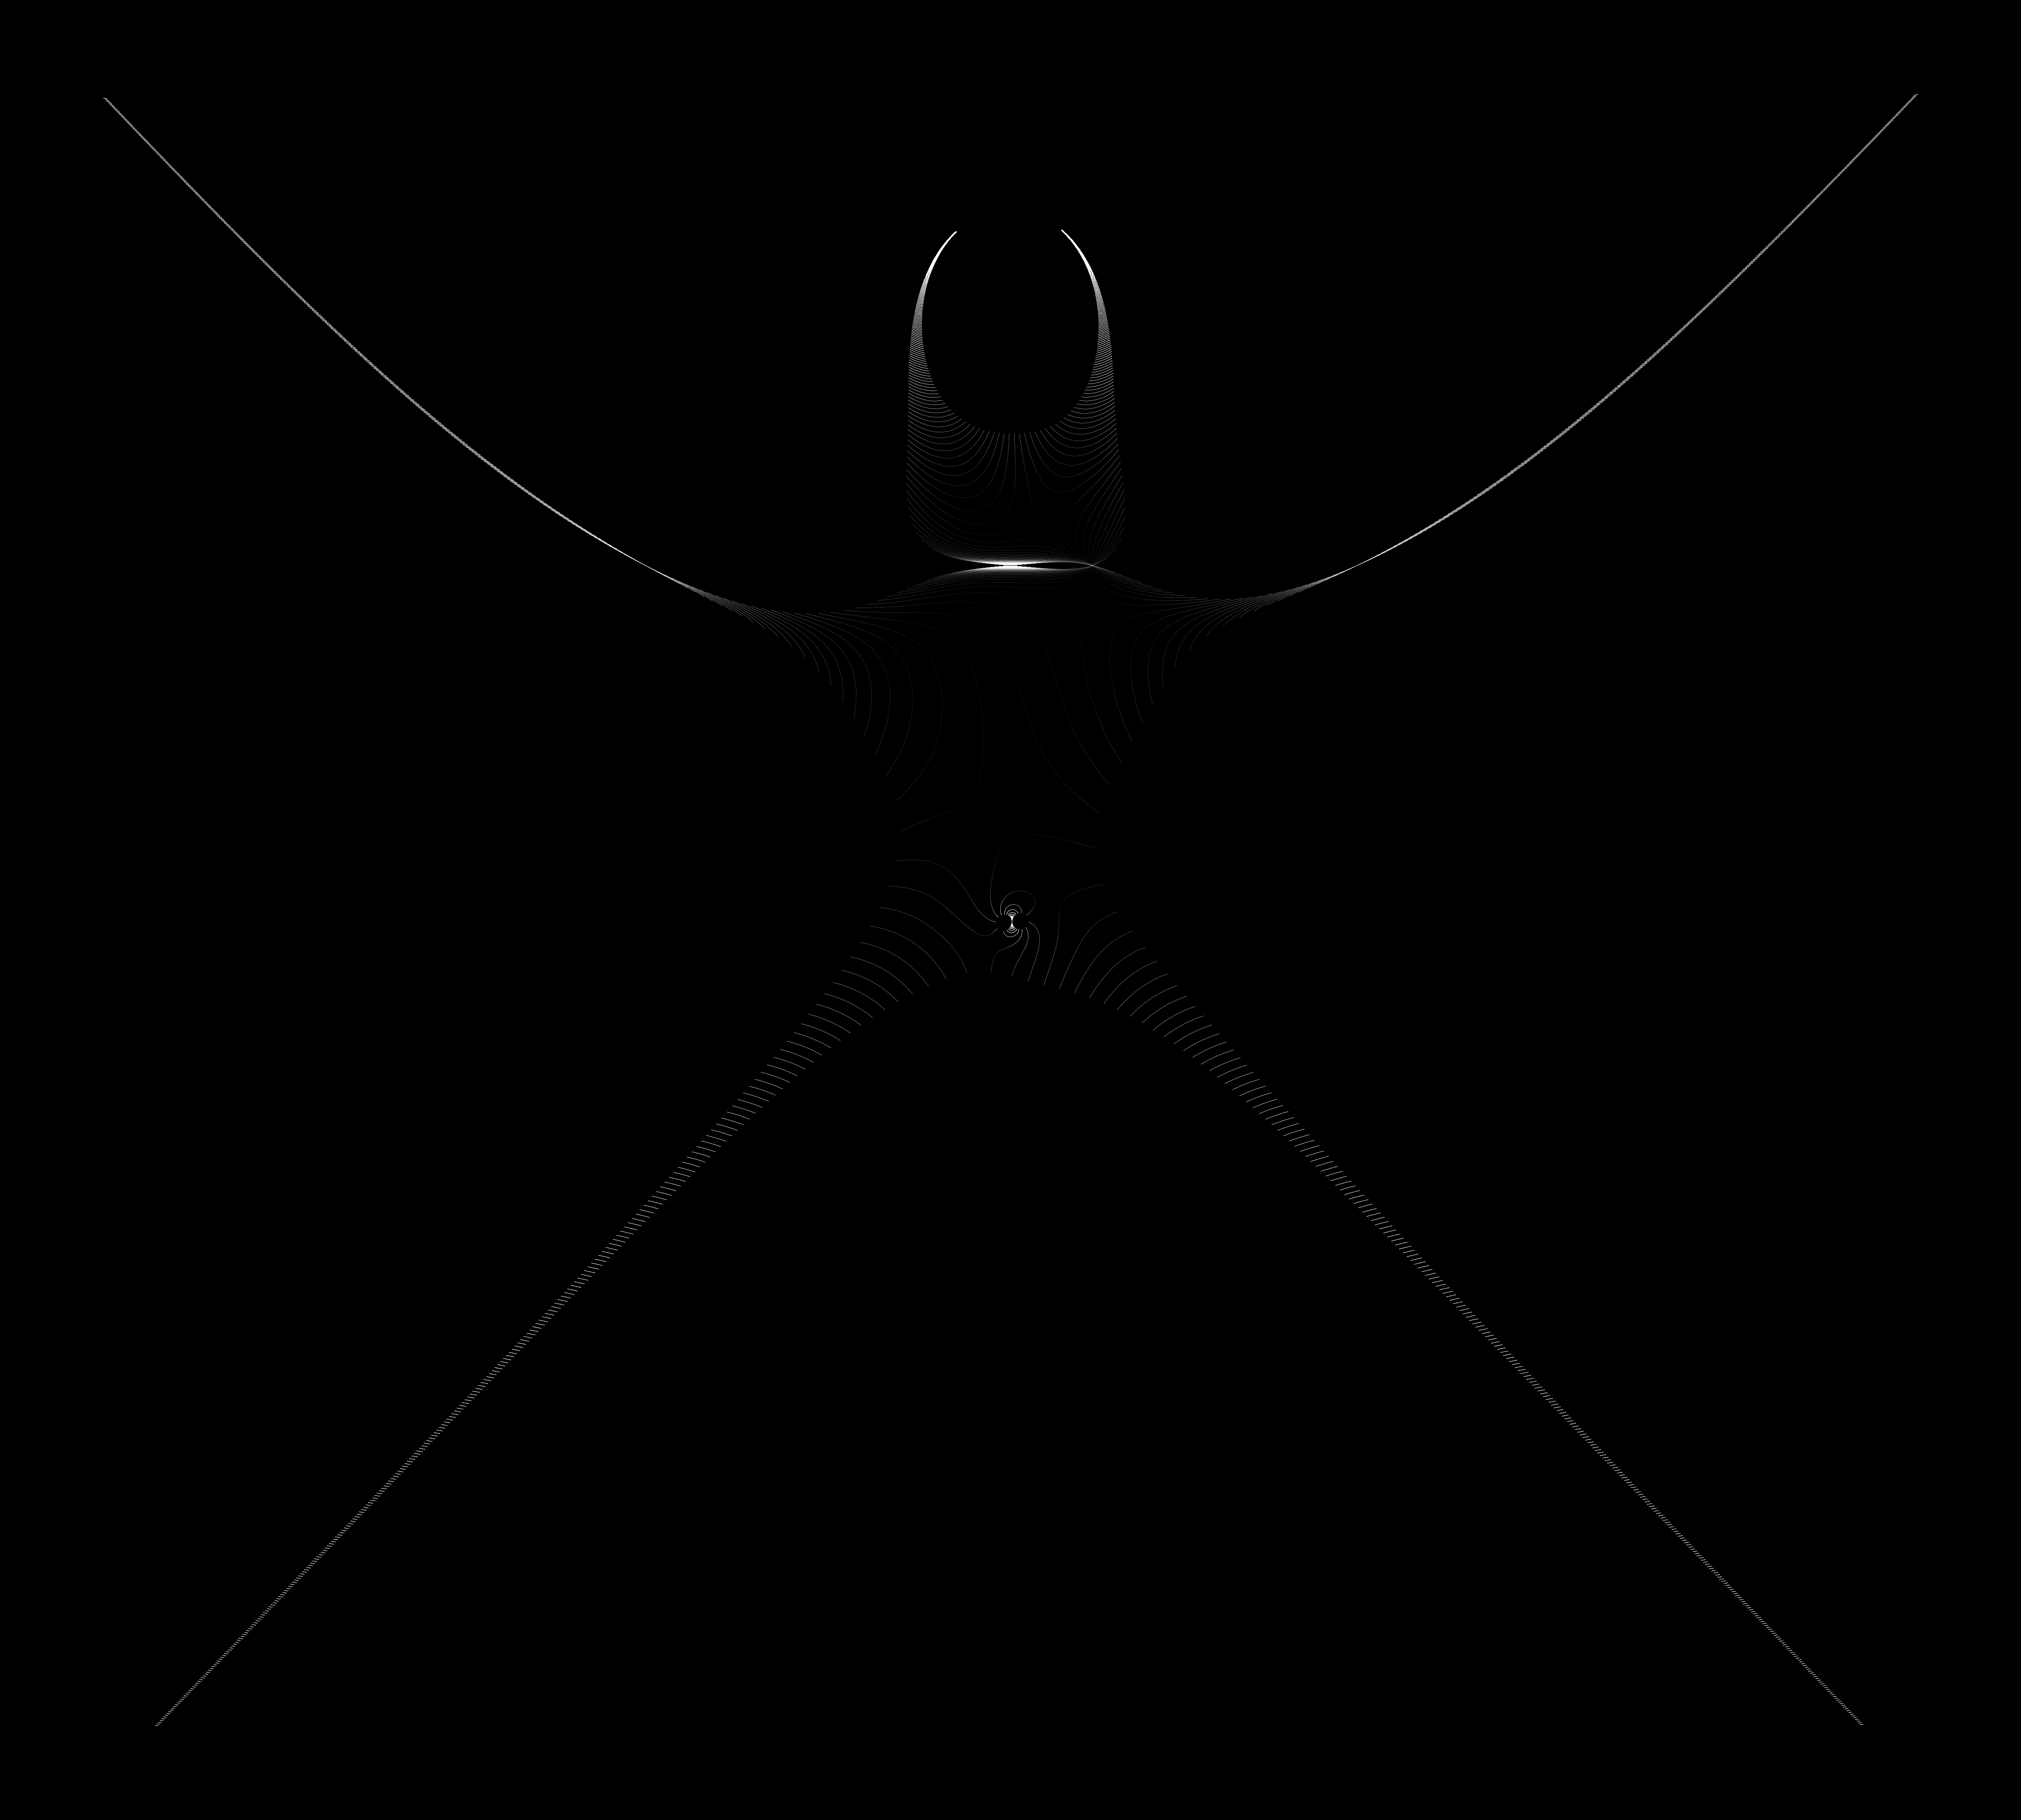

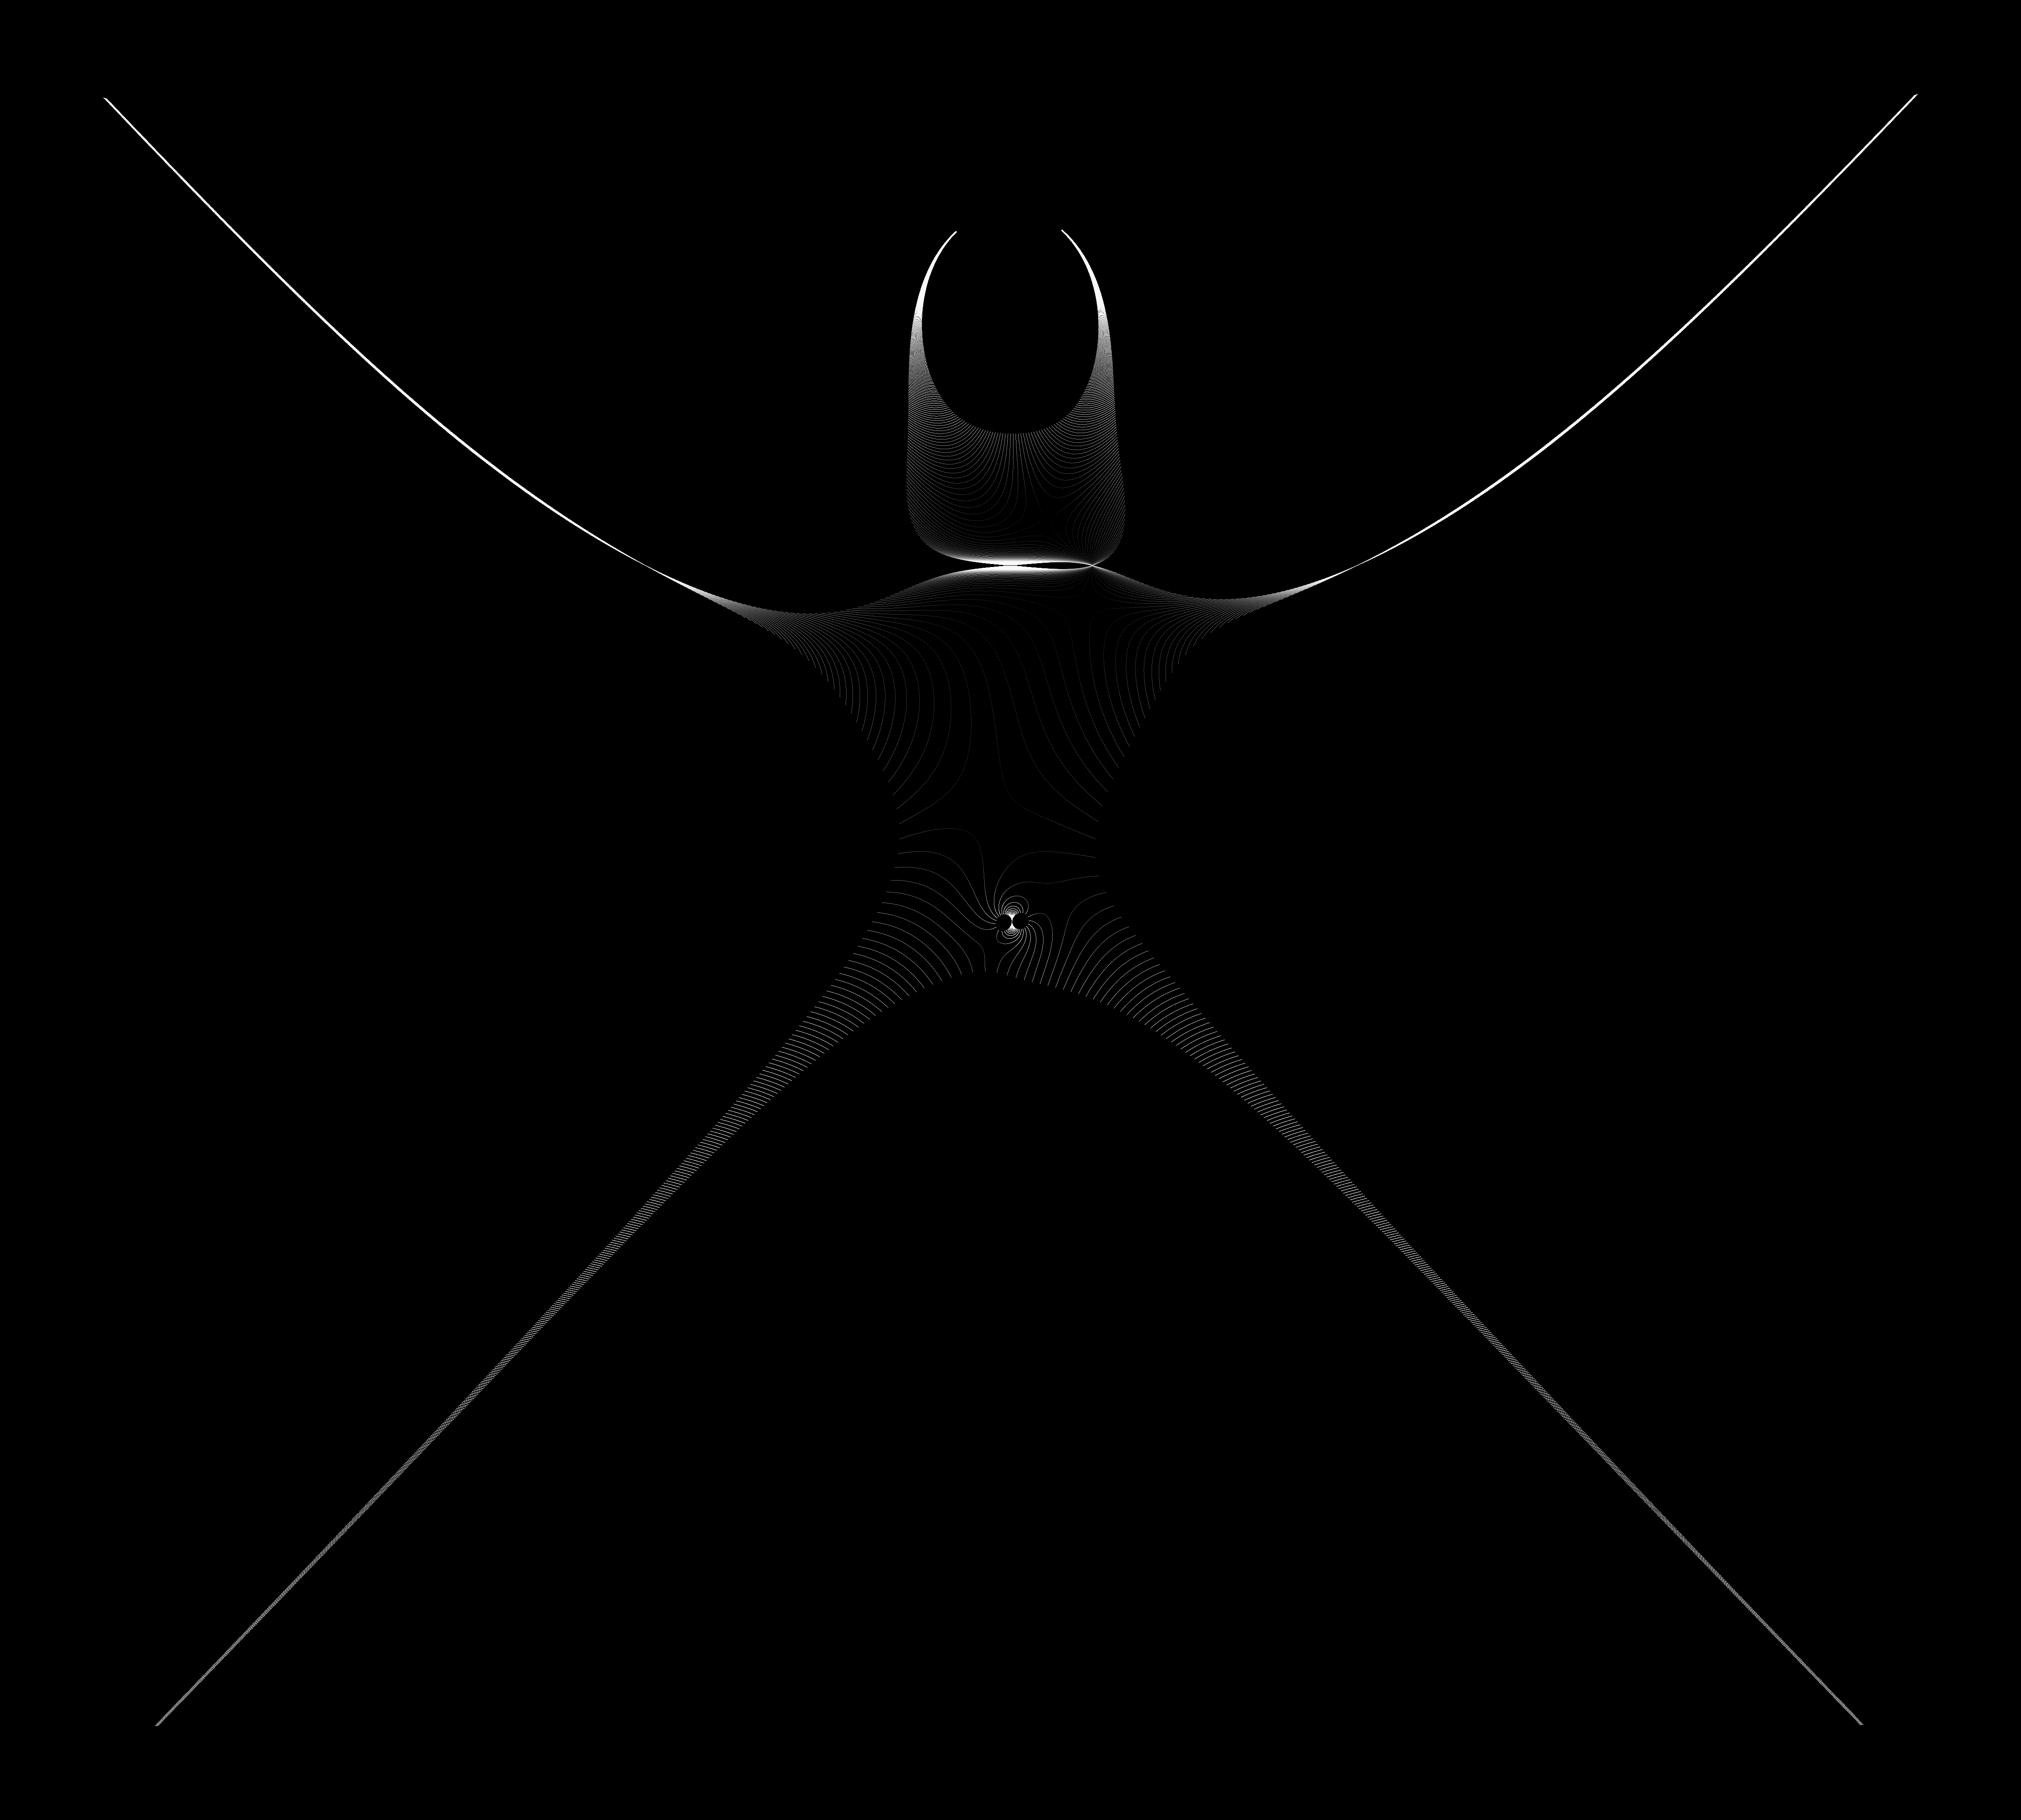

CPU times: total: 29.3 s
Wall time: 29.9 s


In [143]:
%%time
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import eigvals

def solve(l1, l2):
    """
    solves the Eigenman problem (profconradi.com)
    """
    A = np.matrix([
        [   0, -10j, -10j,   l1,   l2],
        [ 10j,    0,  10j,    0,  10j],
        [-0.1,  10j,  10j,    0,    0],
        [-10j,  10j,    0,  10j, -10j],
        [   0,    0,    0, -0.1,  10j]
    ])
    return eigvals(A)

def plot_eigenvals(x, y, fig=None, ax=None, line=None):
    if fig is None and ax is None:
        fig,ax = plt.subplots(figsize=(16,16), dpi=300, facecolor="k")
    ax.scatter(x, y, s=(72./fig.dpi)**2, marker='o', facecolor='white', lw=0, alpha=0.2) #1 pixel marker
    ax.set(facecolor="k")
    ax.set_aspect("equal")
    ax.axis('off')
    fig.tight_layout()
    return fig,ax

for npoints in [5,10,20,50,100,500,1000]:
    fig,ax=None,None
    try:
        x, y = np.loadtxt(f"my_eigenman_n{npoints}.dat", unpack=True)
    except:
        x = []
        y = []
        for l1 in np.linspace(-110,110, npoints):
            for l2 in np.linspace(-110,110, npoints):
                zs = solve(l1,l2)
                x.extend(list(map(lambda z: z.real, zs)))
                y.extend(list(map(lambda z: z.imag, zs)))
        np.savetxt(f"my_eigenman_n{npoints}.dat", np.array([x,y]).T)
    fig,ax = plot_eigenvals(x, y, fig=fig, ax=ax)
    for fmt in ["png"]:
        fig.savefig(f"my_eigenman_n{npoints}.{fmt}")
    plt.show()
#
# npoints | CPU time (s)
# ----------------------- using eig(A) and list(map(re(z)))
#       5 | 1.88
#      10 | 2.75 2.42 2.16
#      20 | 2.20 2.08 2.16
#      50 | 3.23 2.89 3.08
#     100 | 5.73 5.69 5.52
#     500 | 66 80
#    1000 | 256

loaded 125 points
plotting ...
loaded 500 points
plotting ...
loaded 2000 points
plotting ...
loaded 12500 points
plotting ...
loaded 50000 points
plotting ...
loaded 1250000 points
plotting ...
loaded 5000000 points
plotting ...


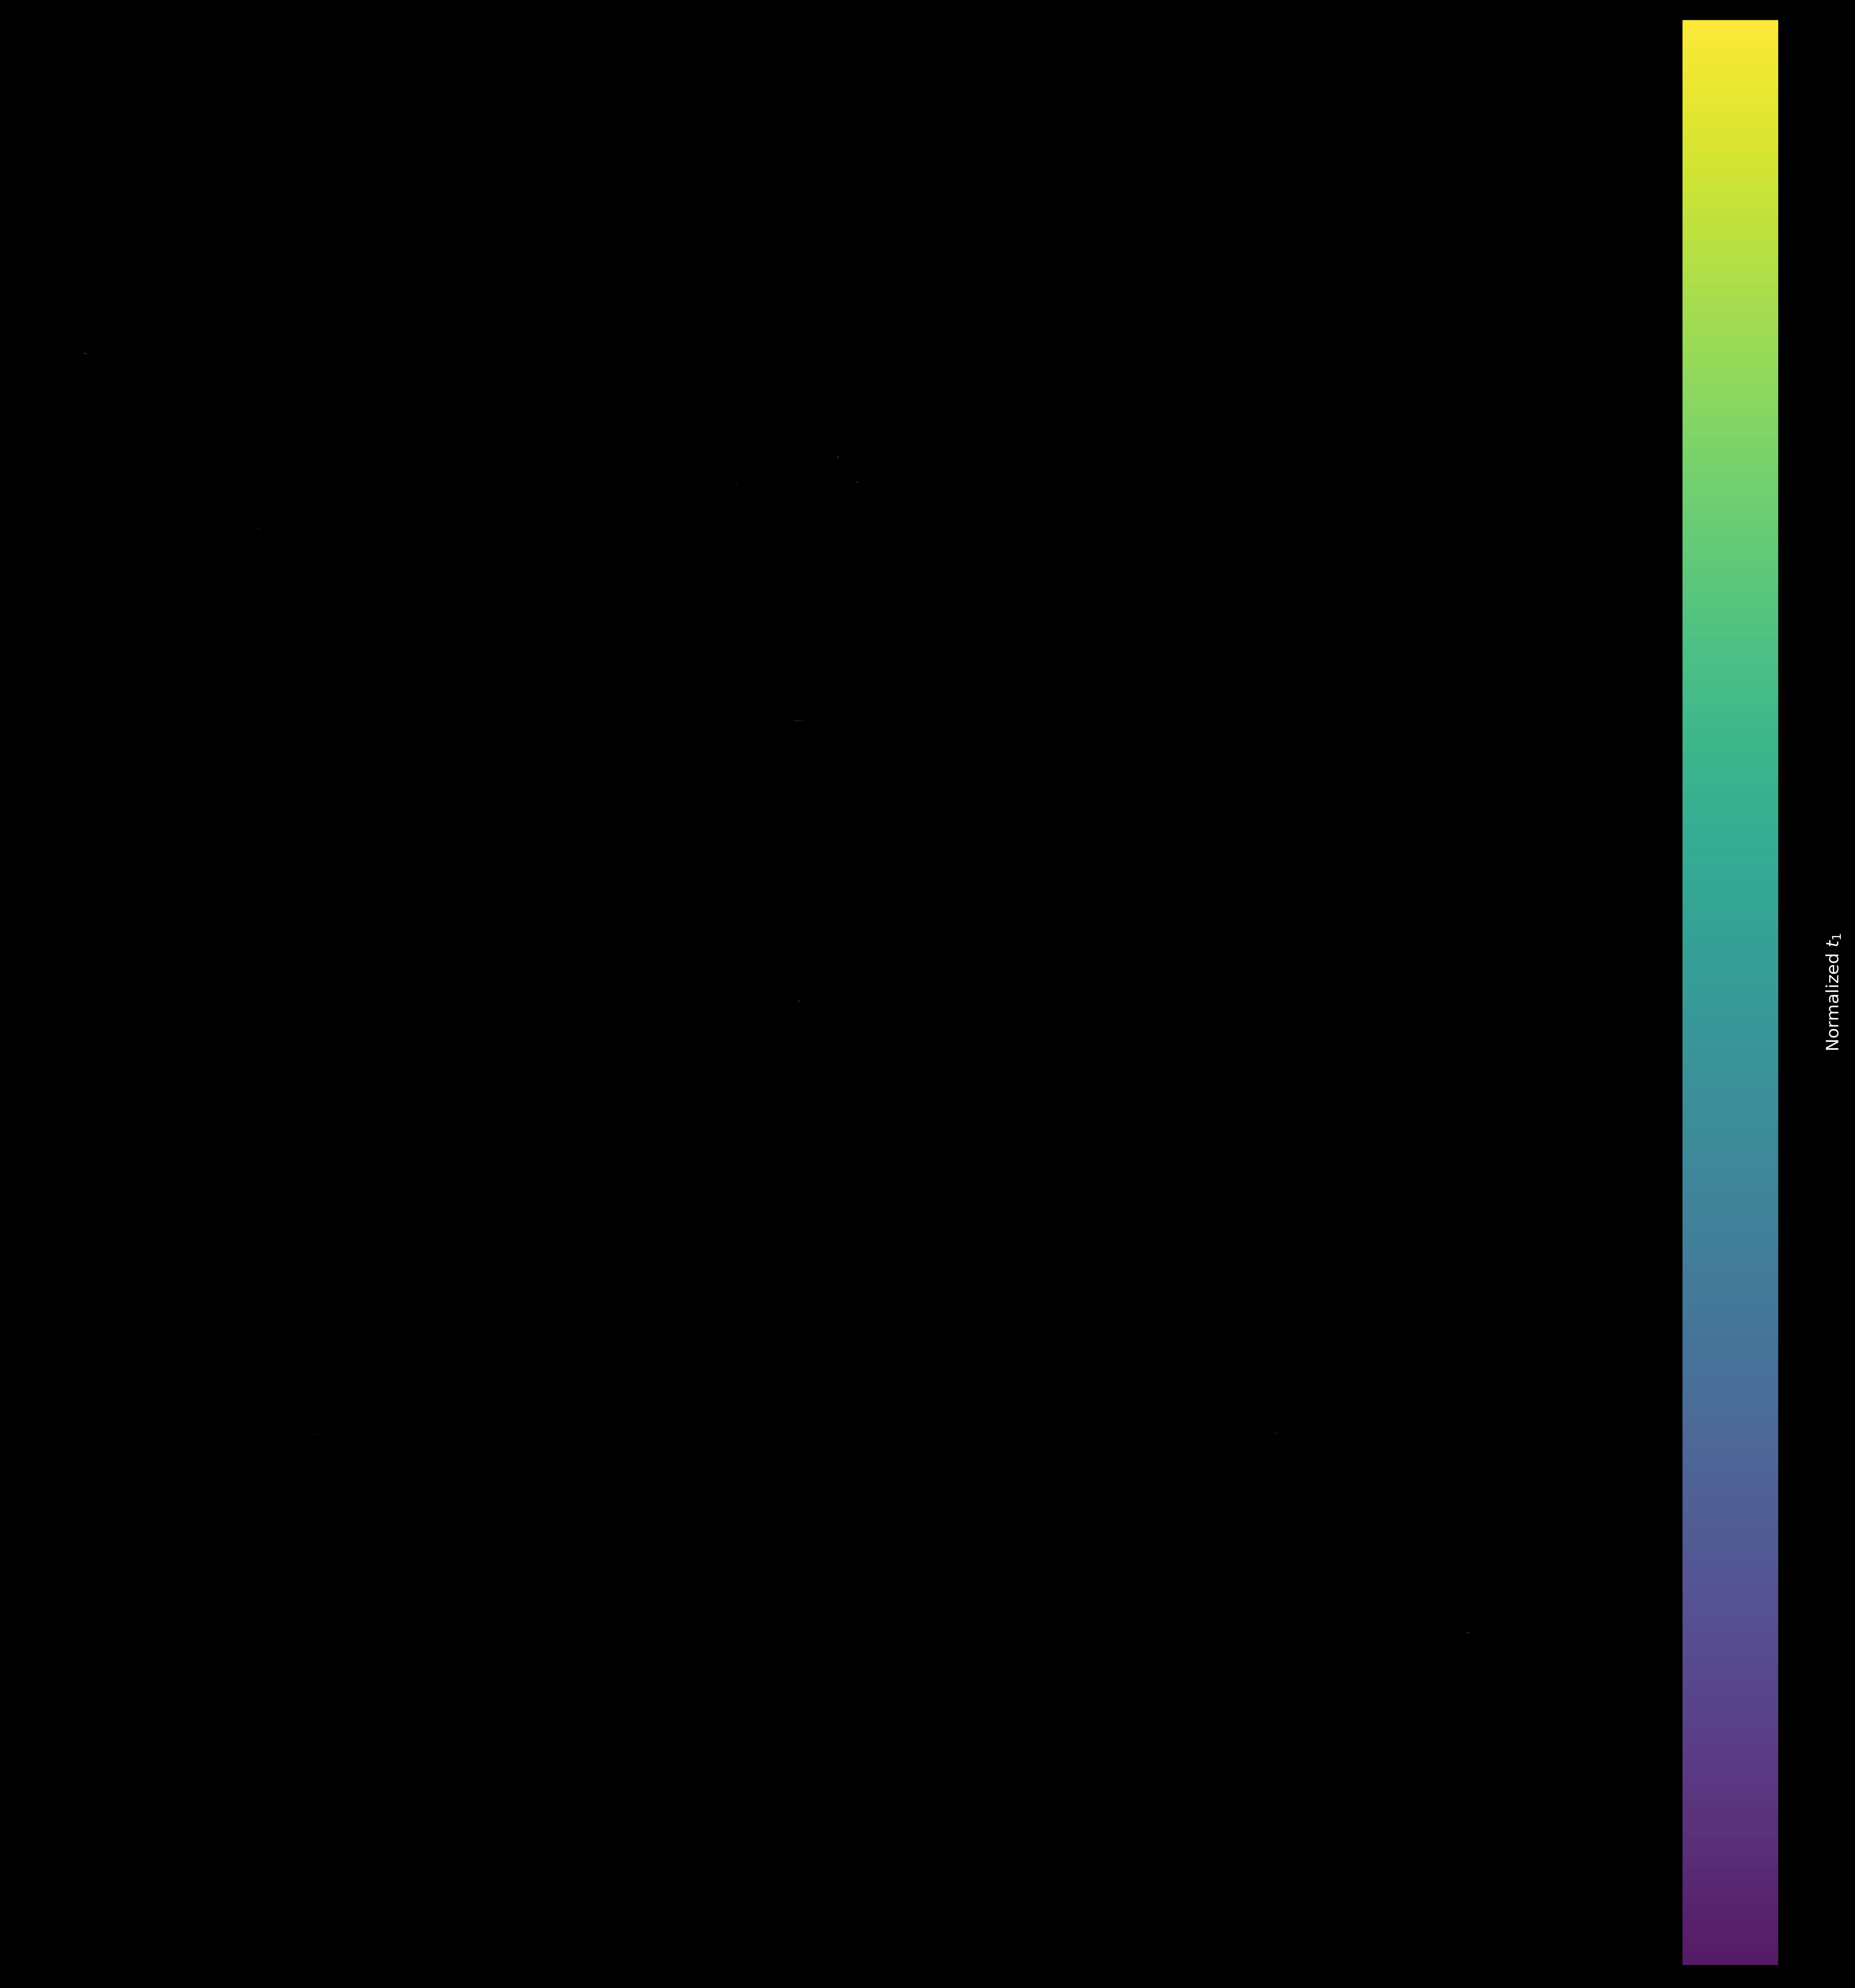

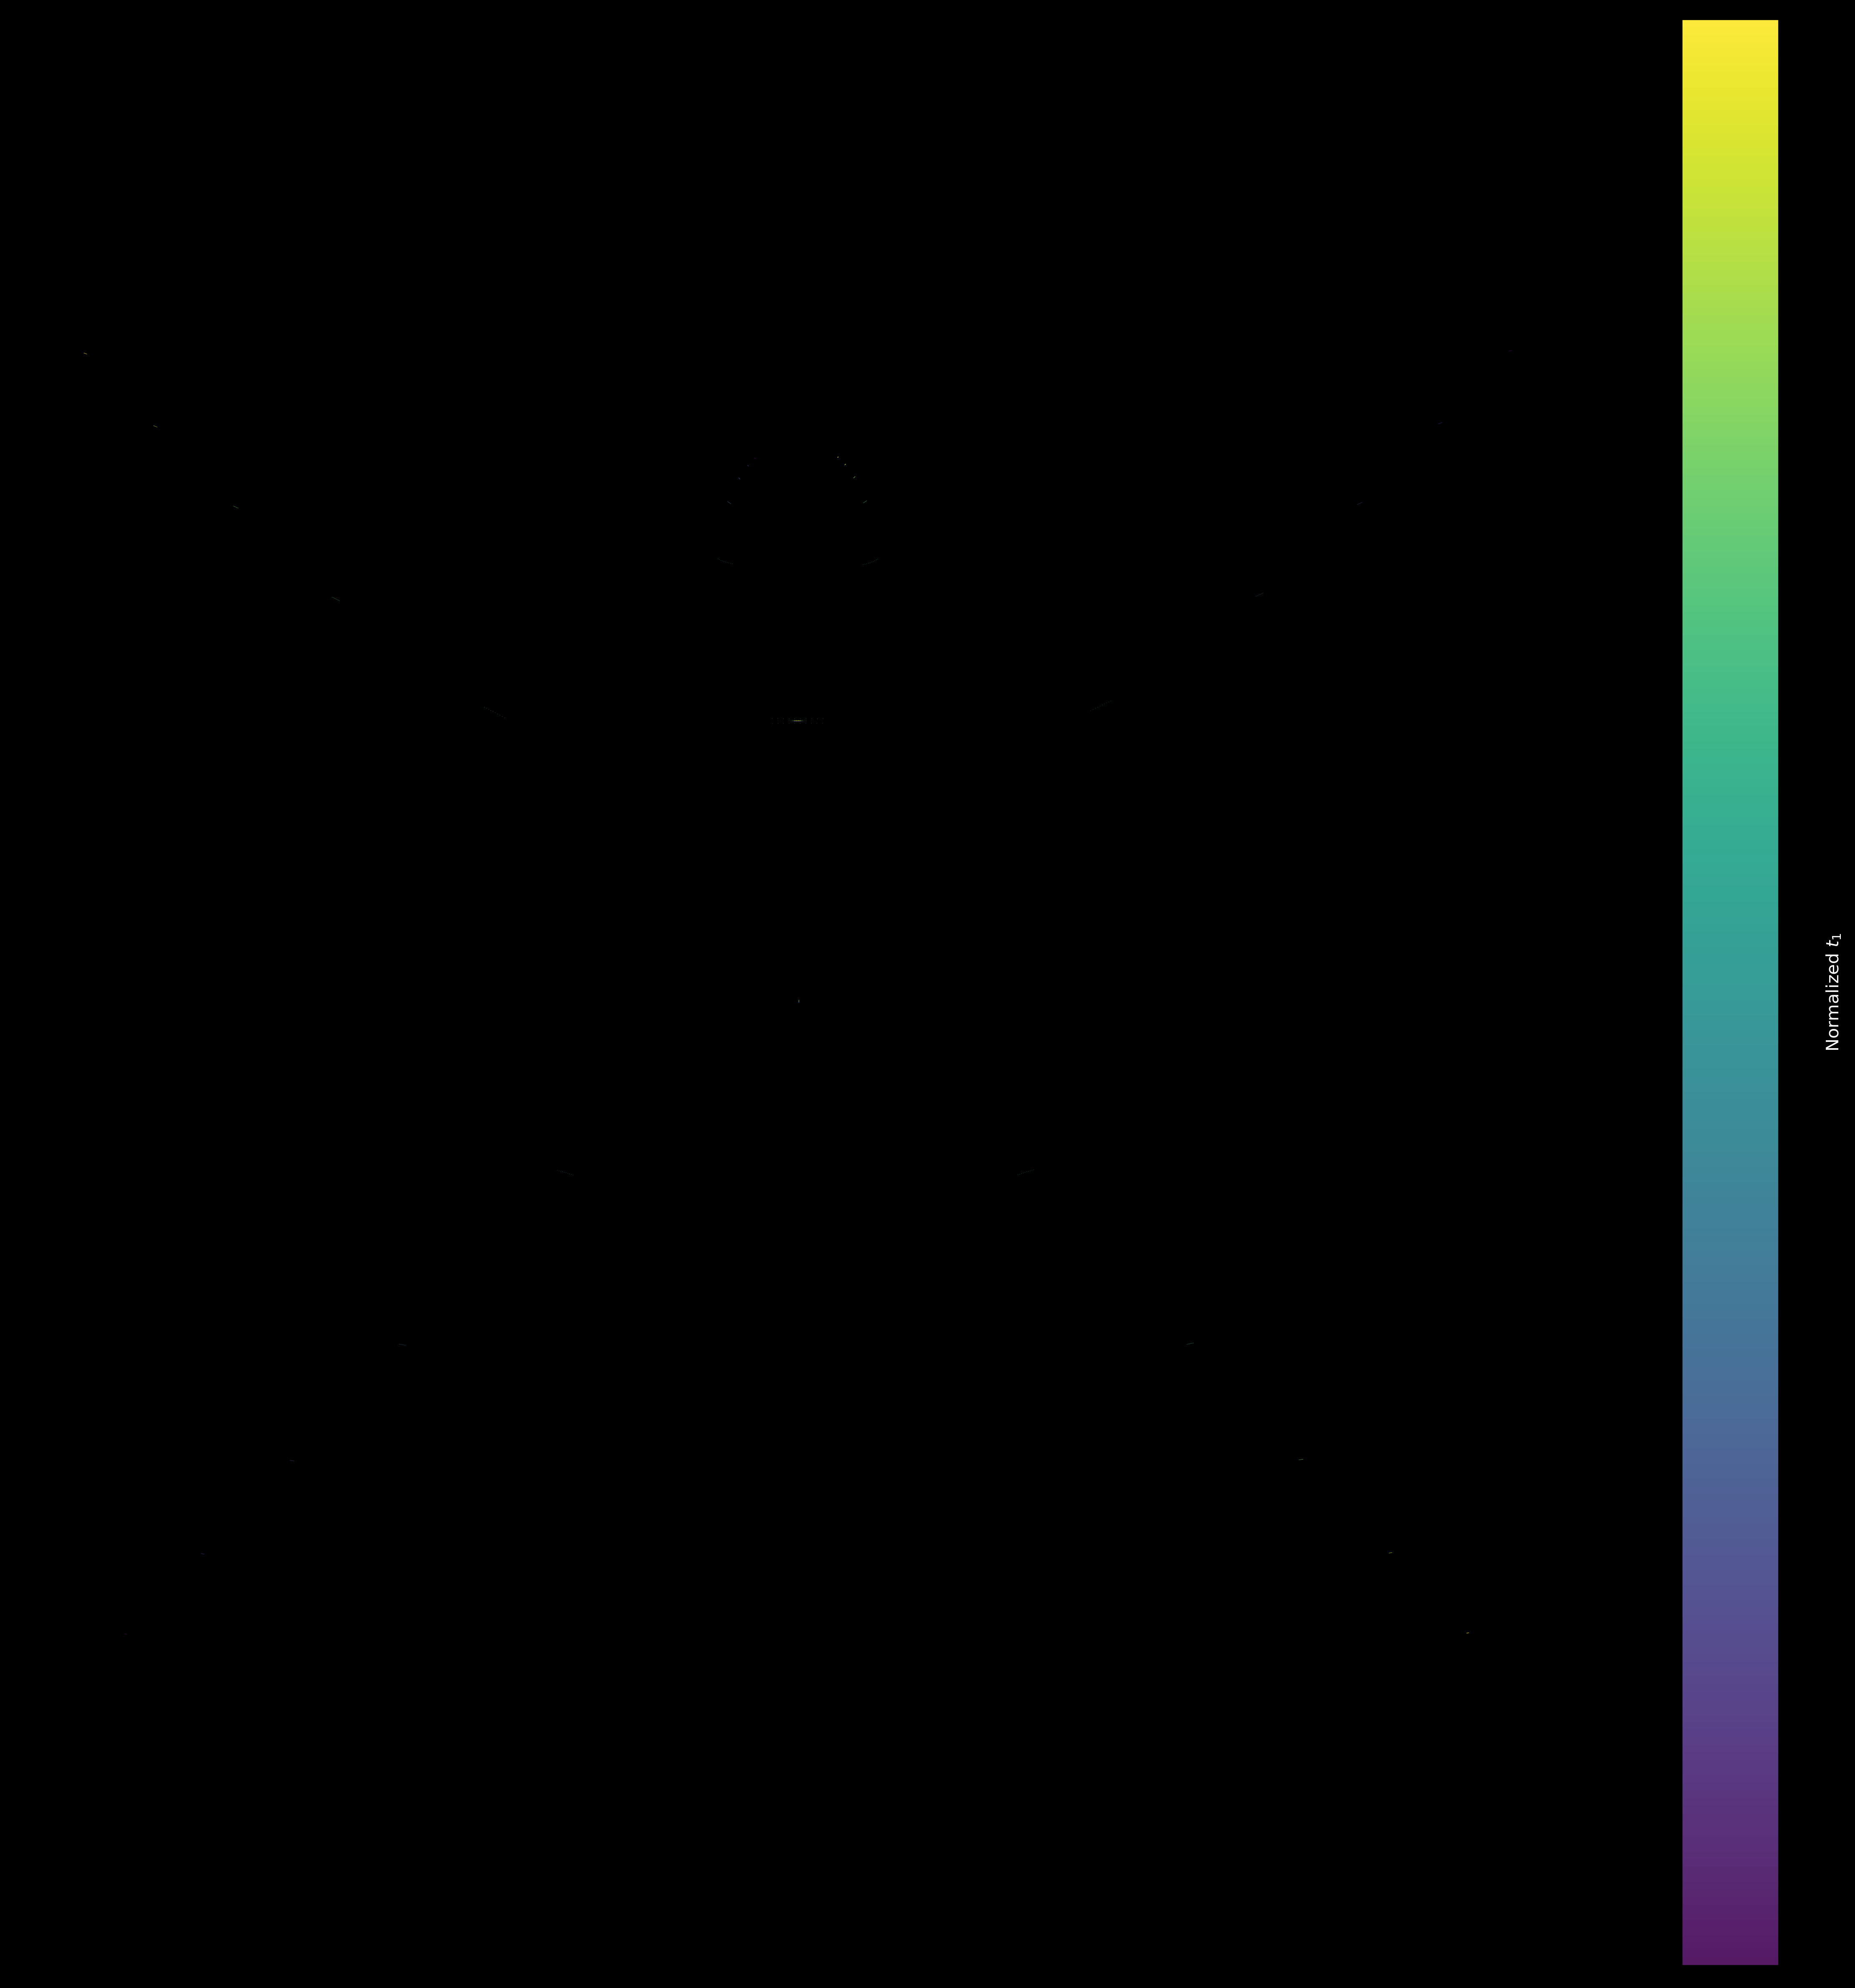

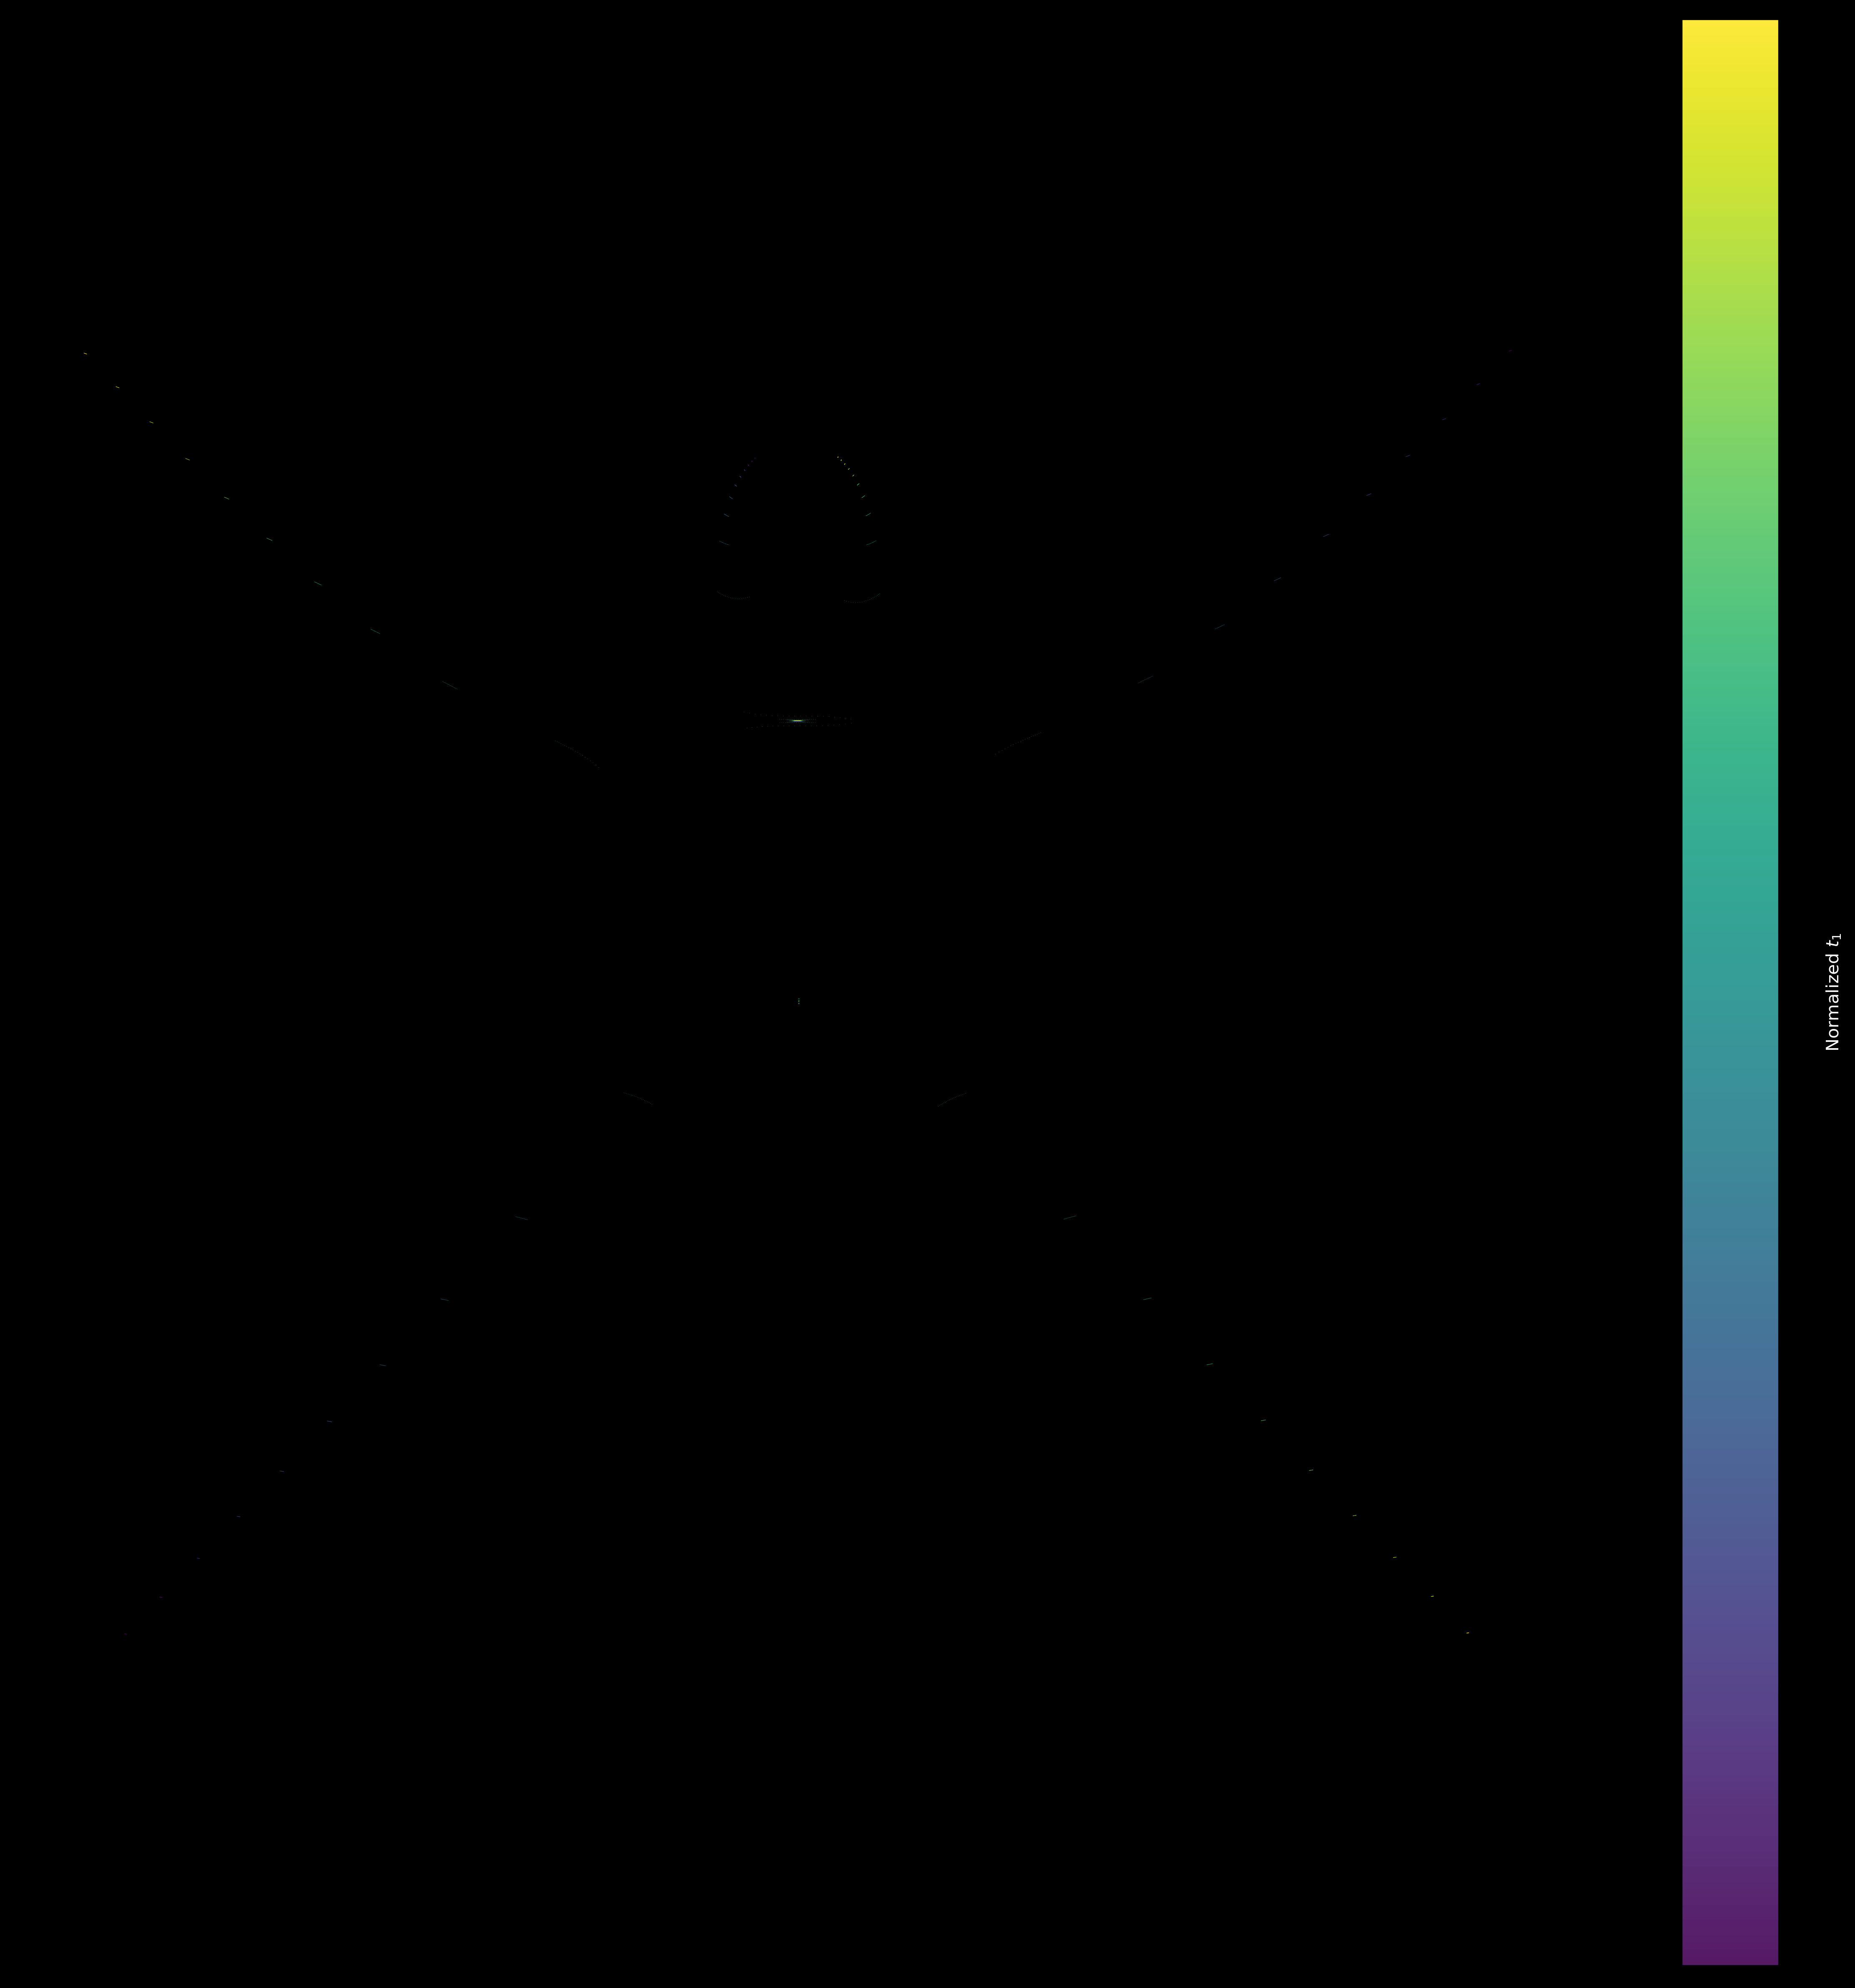

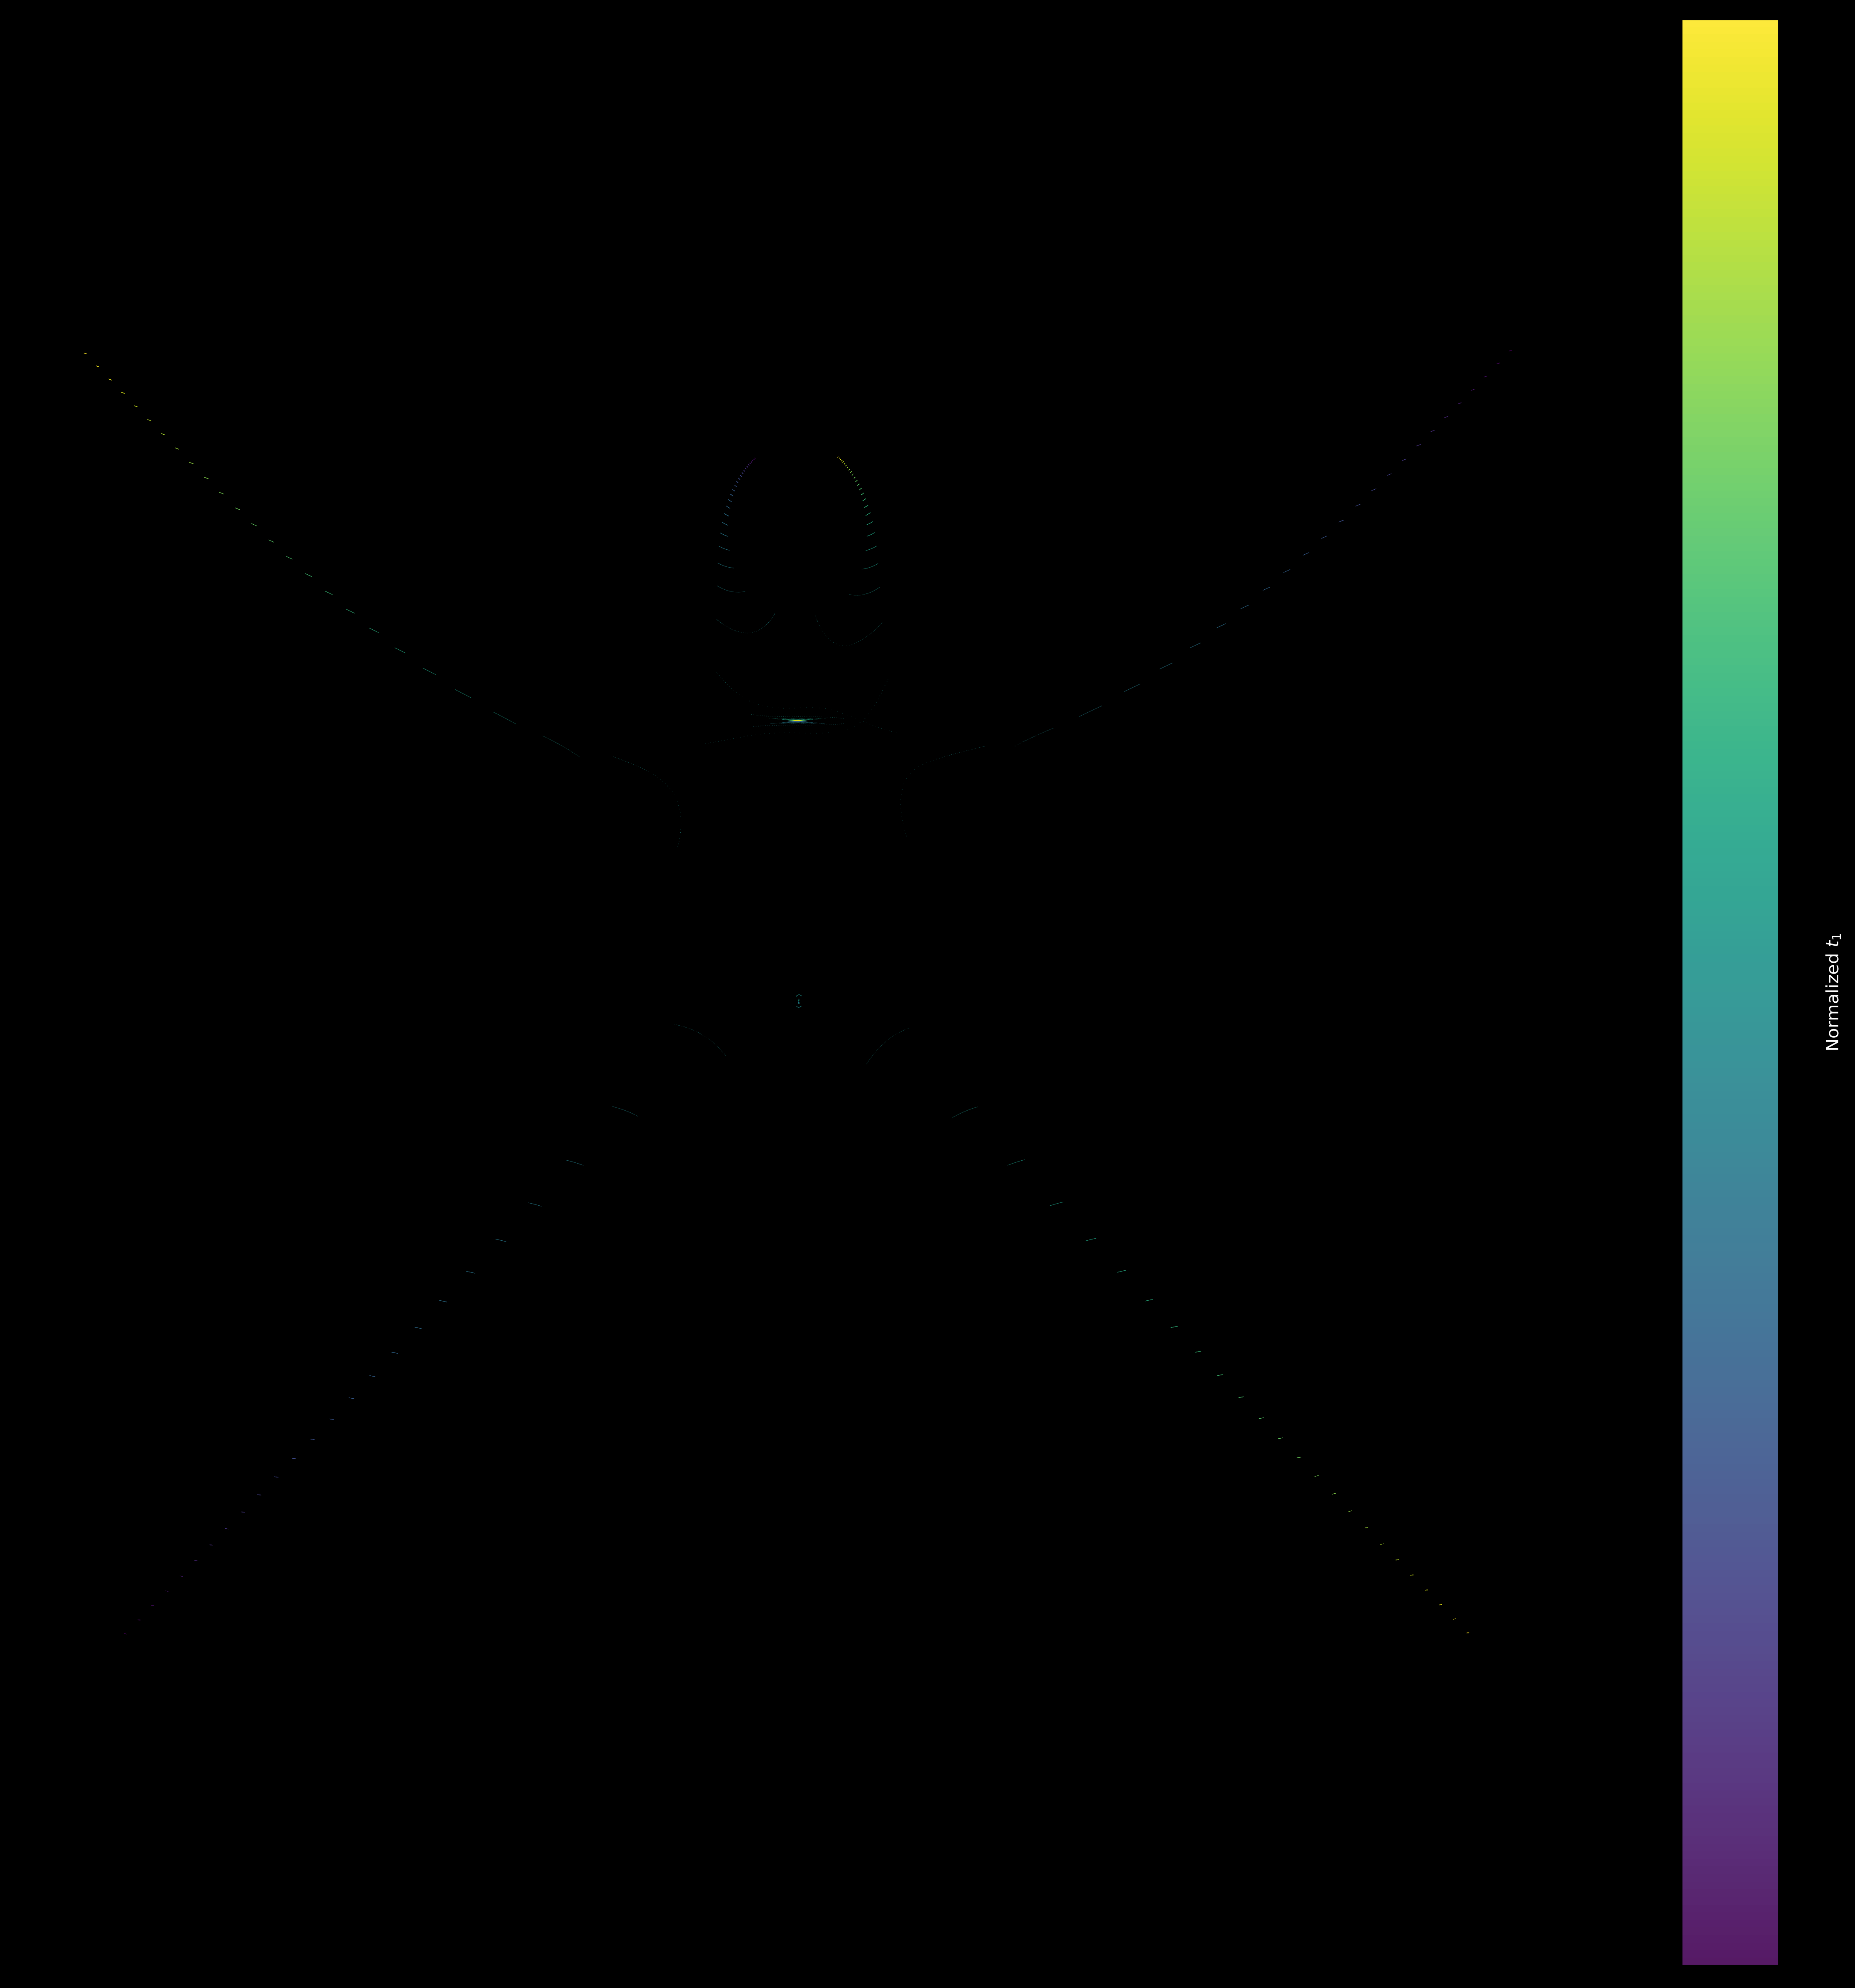

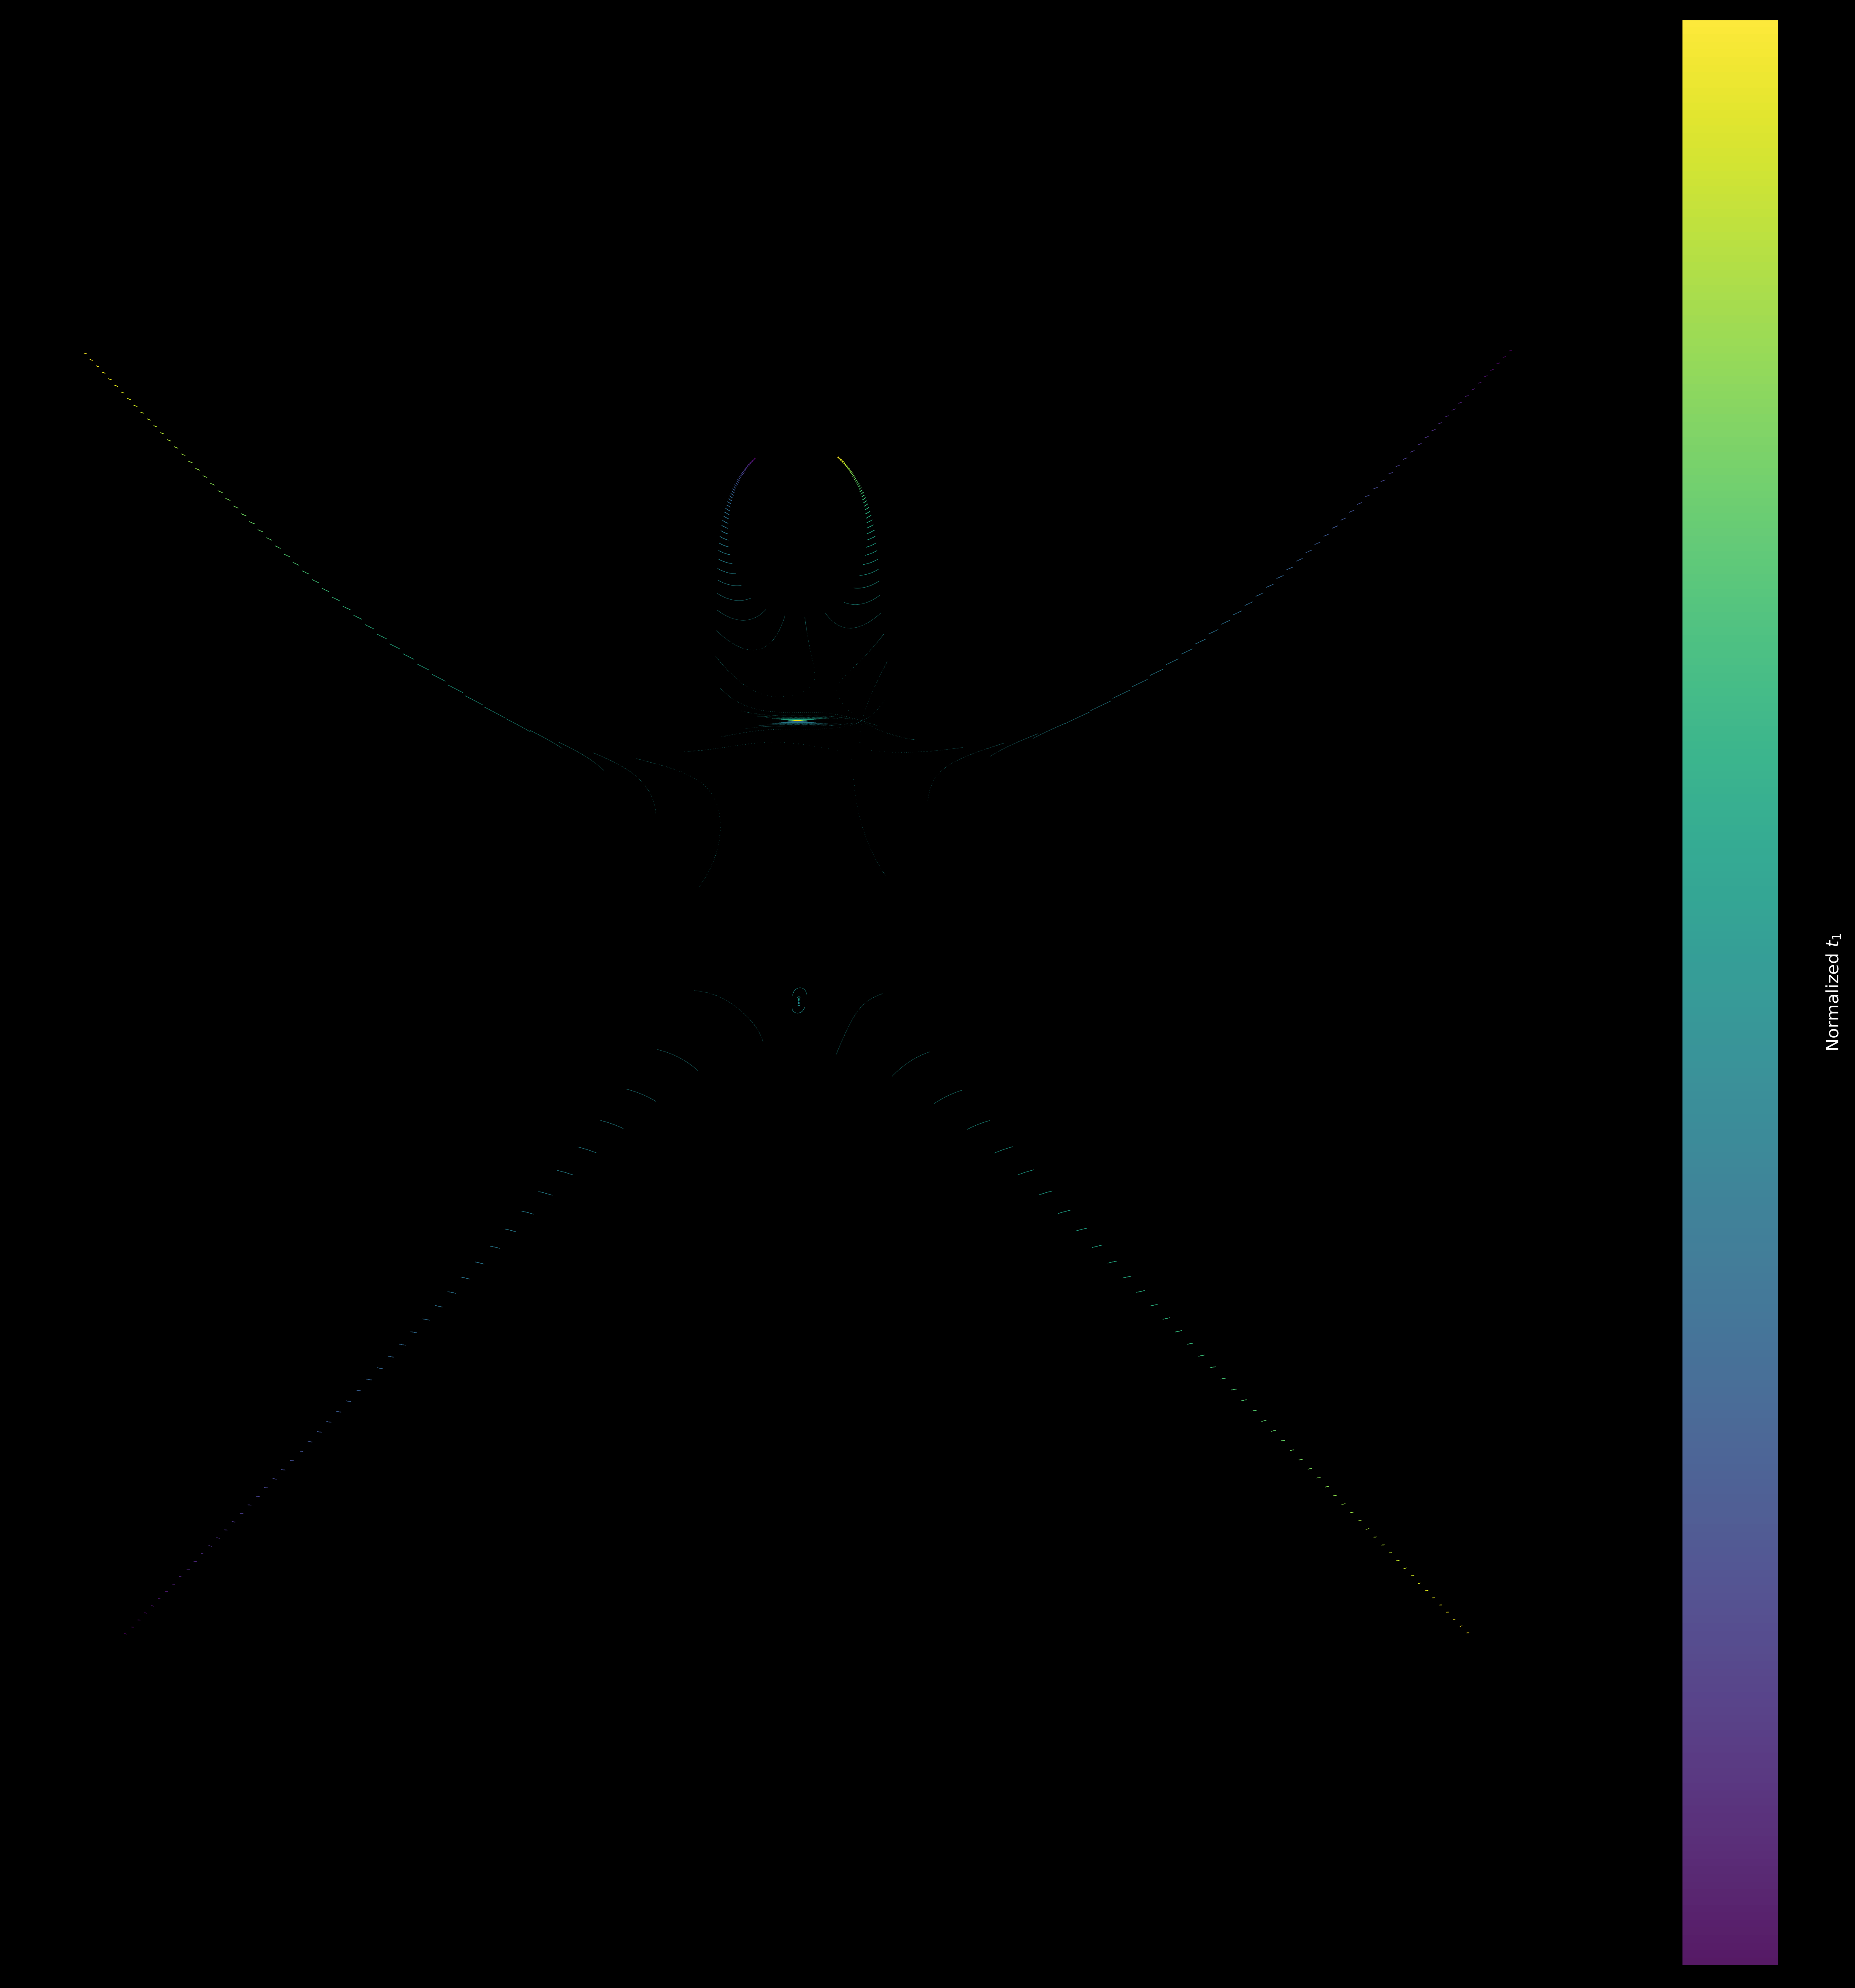

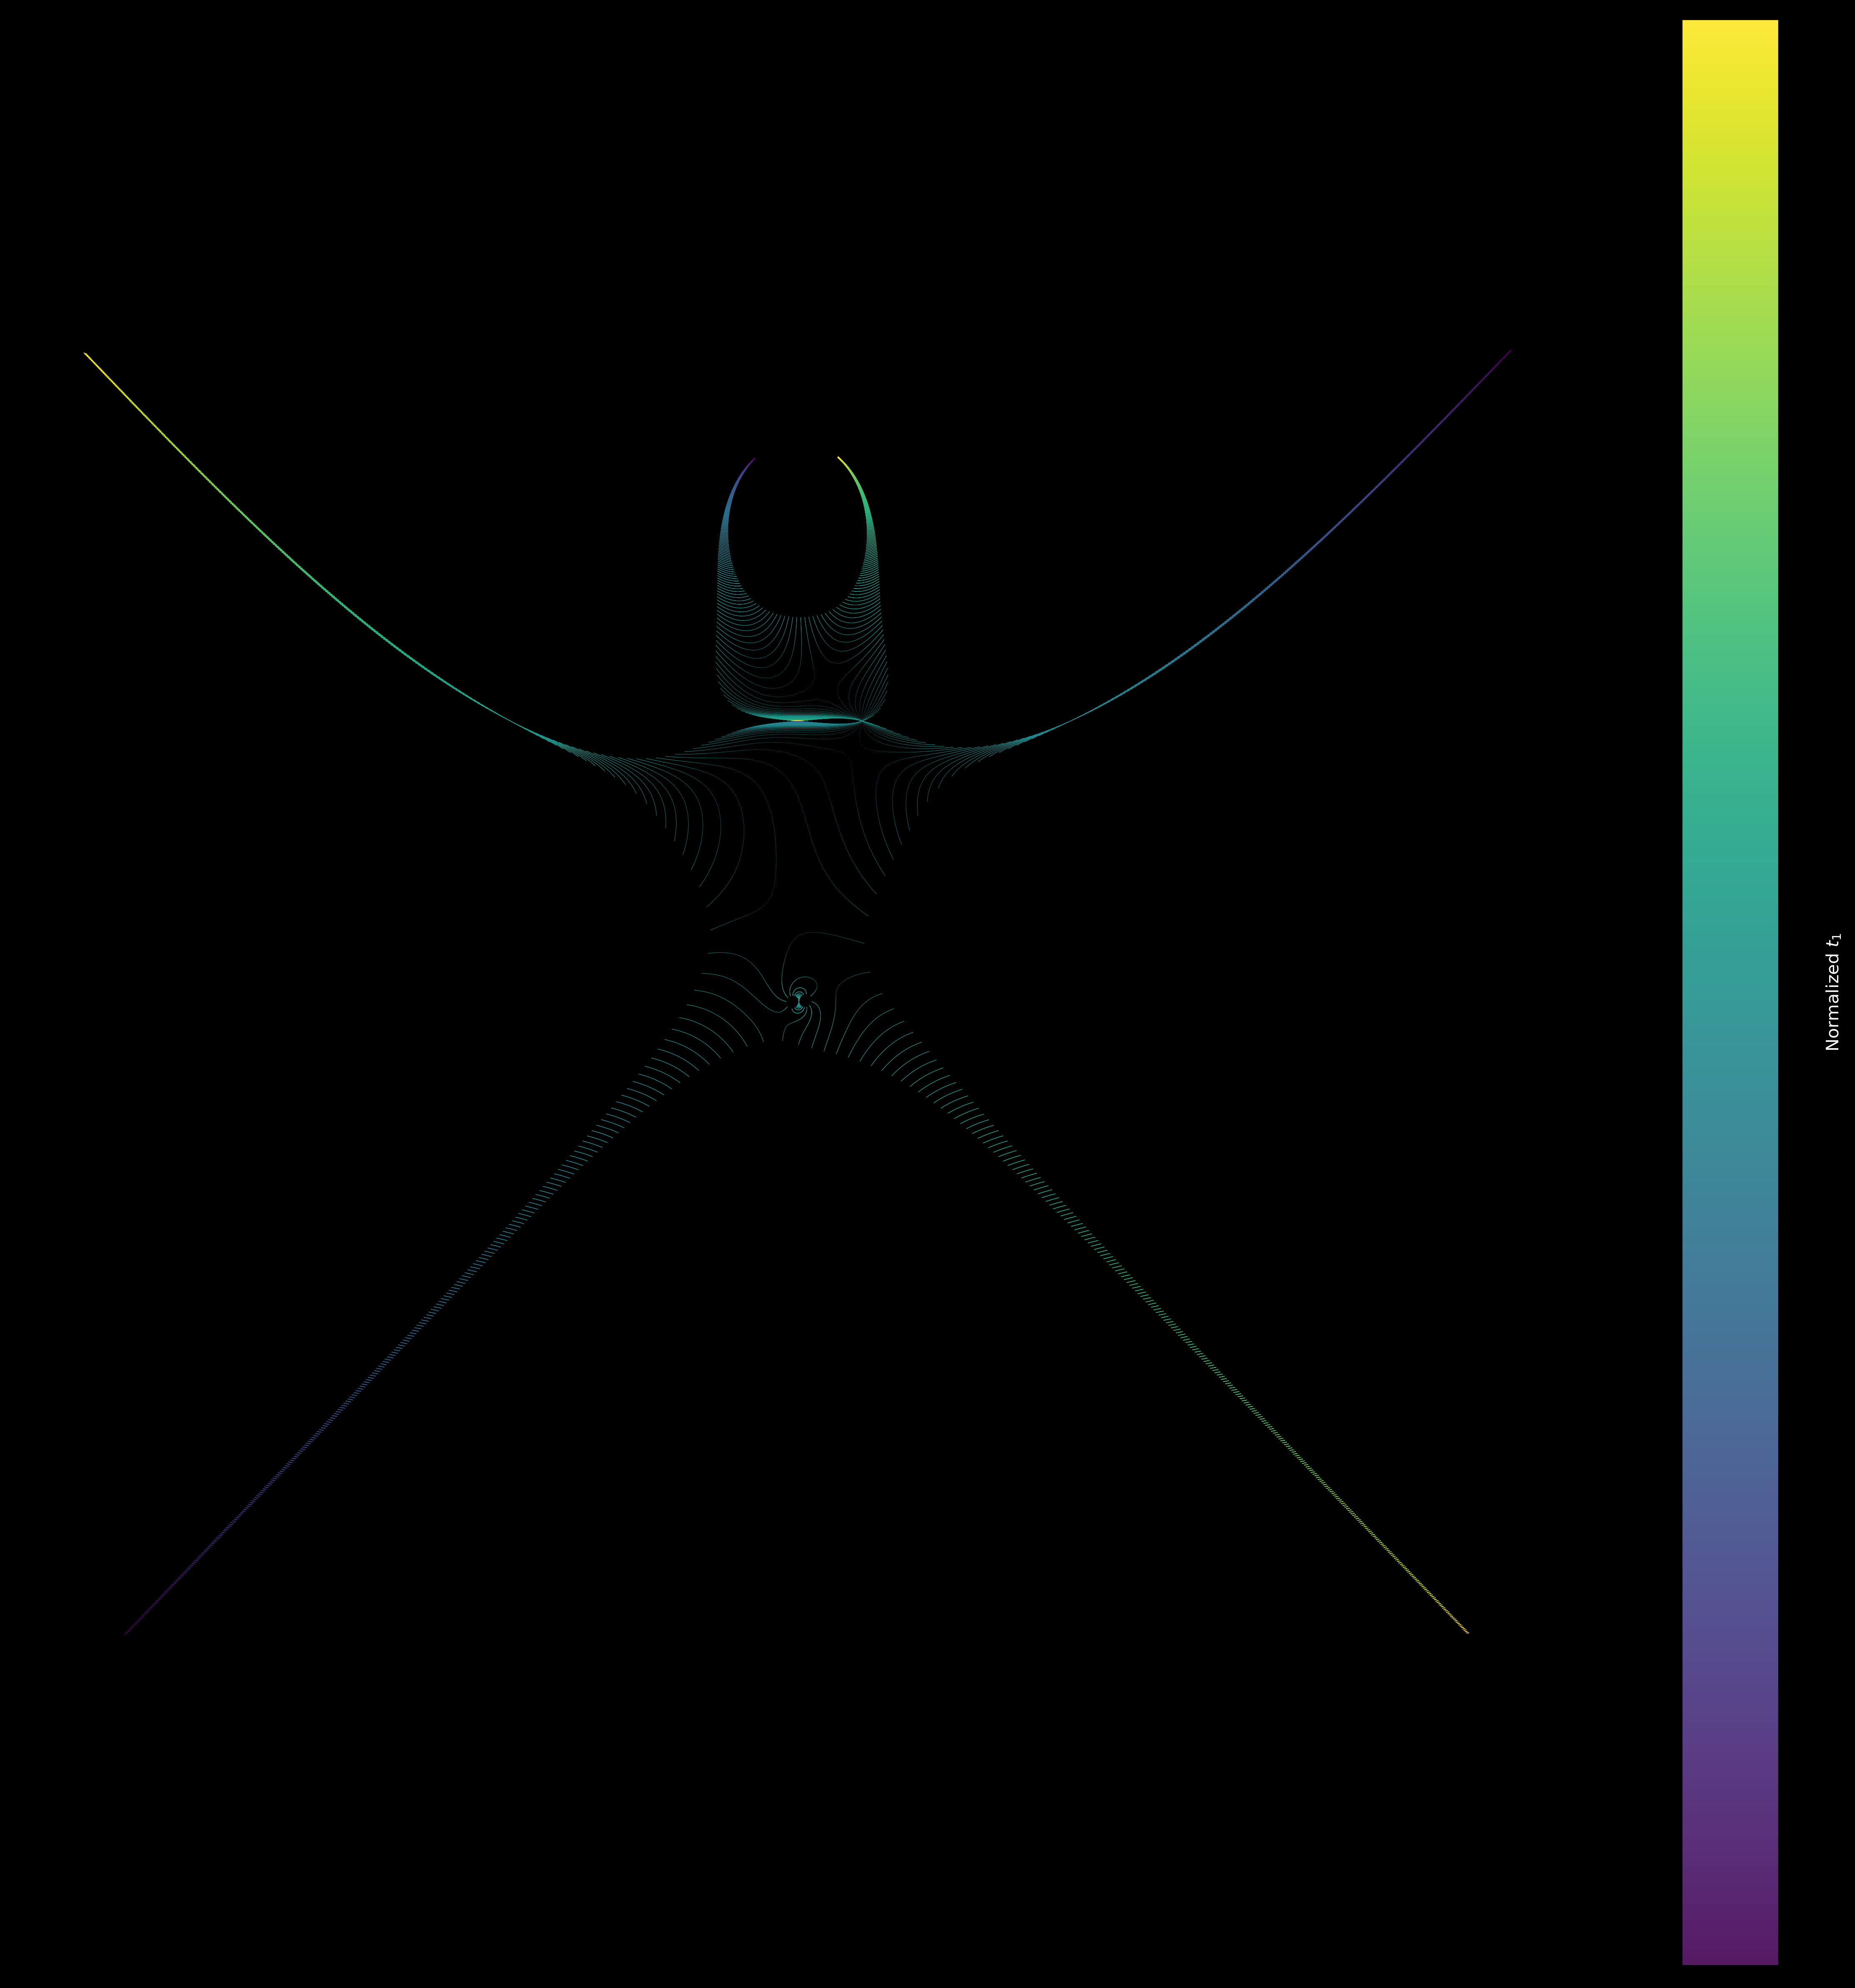

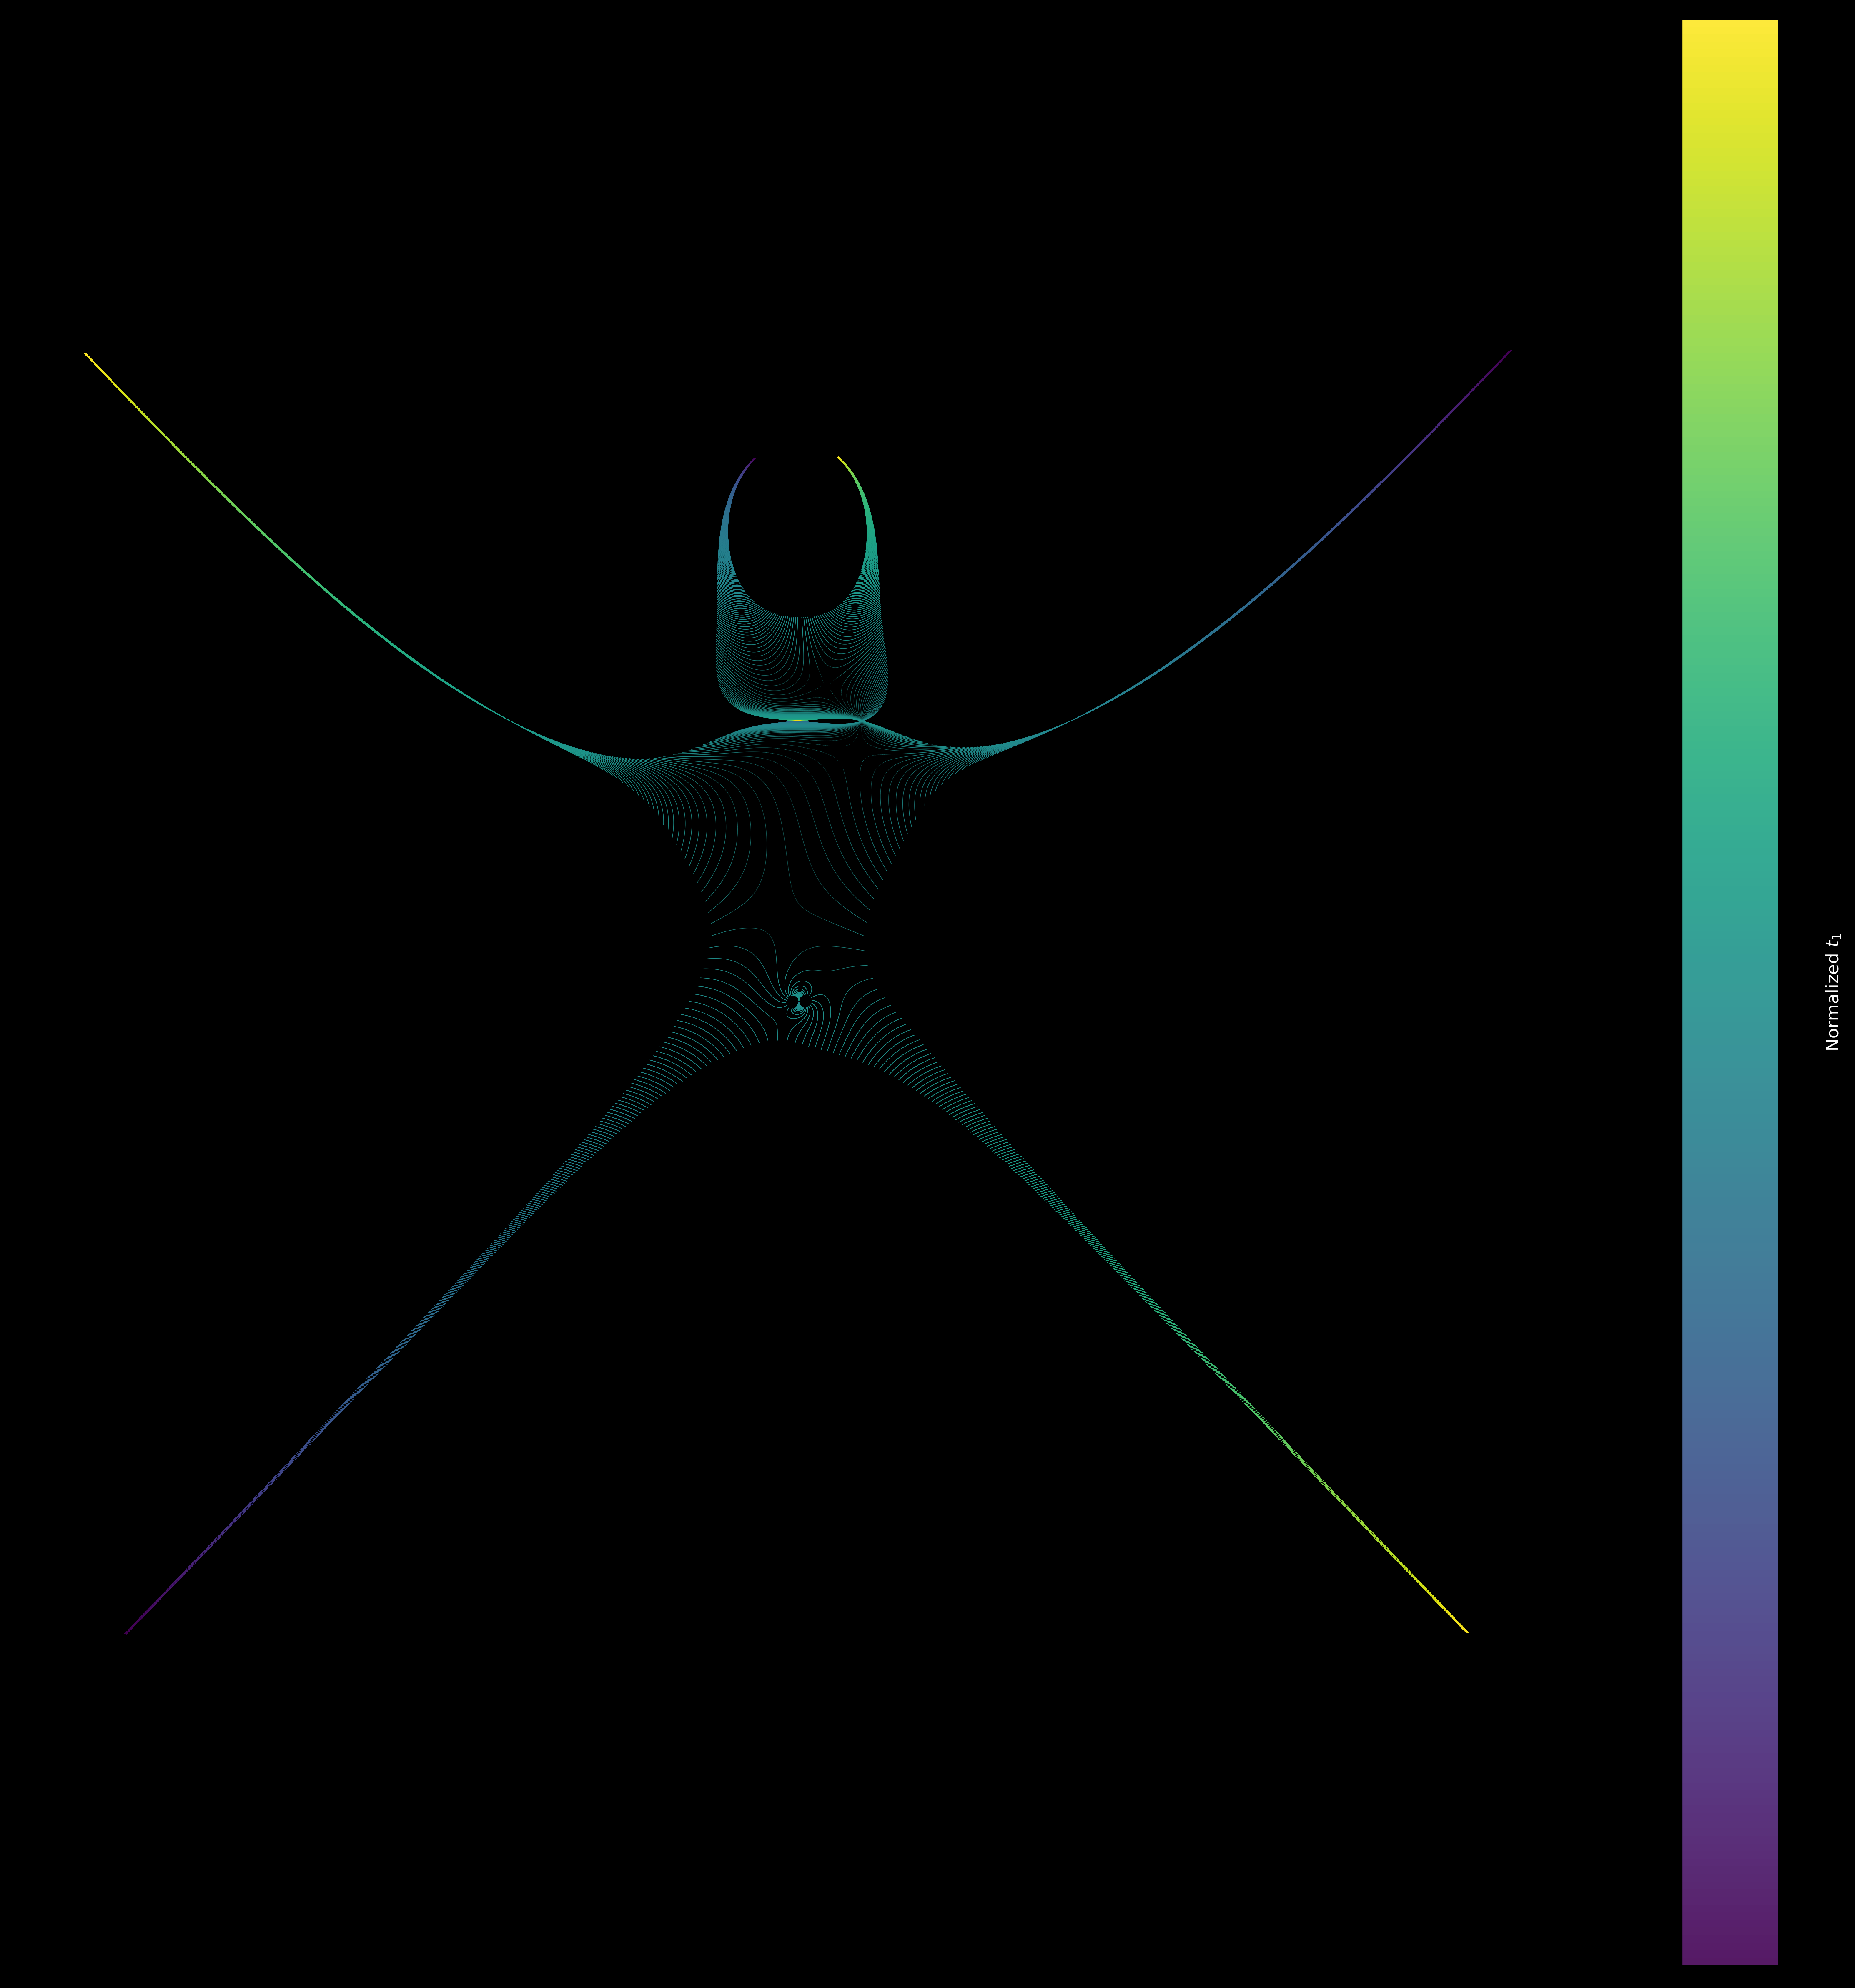

CPU times: total: 1min 37s
Wall time: 1min 40s


In [147]:
%%time
num_eigenvals=5
for npoints in [5,10,20,50,100,500,1000]:
    x, y = np.loadtxt(f"my_eigenman_n{npoints}.dat", unpack=True)
    print(f"loaded {len(x)} points")
    assert len(x)==(len(x)//num_eigenvals)*int(num_eigenvals)
    assert len(x)//num_eigenvals == npoints*npoints
    l1 = []
    l2 = []
    for l1_ in np.linspace(-110,110, npoints):
        for l2_ in np.linspace(-110,110, npoints):
            l1.append([l1_]*num_eigenvals)
            l2.append([l2_]*num_eigenvals)
    l1 = np.array(l1)
    l2 = np.array(l2)
    c=l1
    c=(c-c.min())/(c.max()-c.min())
    fig,ax = plt.subplots(figsize=(16,16), dpi=300, facecolor="k")
    print("plotting ...")
    line = ax.scatter(x, y, s=(72./fig.dpi)**2, marker='o', lw=0, alpha=0.9, c=c, cmap="viridis")
    cbar = fig.colorbar(line)
    cbar.ax.set_ylabel(f"Normalized $t_1$", color="white")
    ax.set_aspect("equal")
    ax.axis('off')
    fig.tight_layout()
    for fmt in ["png"]:
        fig.savefig(f"my_eigenman_l1cmap_n{npoints}.{fmt}")
plt.show()